# <font color=#0099CC>**Construcción de una Cartera de Fondos Sesgada a Asia Pacífica**</font>

### **Fecha: 09/04/2026 | Autor: Javier Fernández Guerra**

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### Contexto y propósito del documento

Este cuaderno documenta un estudio cuantitativo para diseñar un fondo de fondos (FoF) orientado a la renta variable de Asia Pacífico excluyendo Japón. El relato de partida es el de una casa de gestión que desea posicionar su cartera de fondos con sesgo claro hacia ese mercado ante expectativas favorables de rendimiento; el contenido que sigue es metodológico y académico —no constituye asesoramiento de inversión ni una oferta comercial.

El mandato que se simula se acerca a la replicación amplia del comportamiento factorial del mercado asiático: interesa que el conjunto de fondos subyacentes exhiba, en agregado, una exposición estable al factor de mercado regional y a los estilos capturados por el modelo de Fama y French, más que la búsqueda de **alpha** de gestores individuales. La coherencia del diseño se evalúa al final con indicadores habituales (correlación, tracking error, beta) frente a un activo de referencia líquido; esa comparación sirve como contraste ex post, no como motor de la selección.

El flujo de trabajo enlaza dos bloques habituales en formación en **machine learning** aplicado a finanzas: preprocesado de datos e ingeniería de características a partir de series de precios, reducción de dimensionalidad, y aprendizaje no supervisado para agrupar activos y extraer reglas de construcción de cartera. Así se da continuidad entre la preparación del universo y el análisis de **clusters** sobre el que se apoya la decisión de ponderaciones.


### Datos empleados

- **Valores liquidativos diarios (NAV)** de un universo amplio de fondos de inversión (del orden de 25.000 identificadores distintos) entre el 5 de enero de 2016 y el 16 de julio de 2021, suministrados por IronIA en el fichero `navs.pickle` descrito en el enunciado.
- **Factores diarios de Fama y French** para **Asia Pacífico ex Japan** (entre otros, Mkt-RF, SMB, HML, MOM), obtenidos de la [Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) de Kenneth French; su localización y descarga corren a cargo del análisis, como en el planteamiento oficial de la práctica.
- **ETF iShares MSCI All Country Asia ex Japan (ticker AAXJ)**, reservado en este diseño exclusivamente para una fase de validación final, en analogía con un conjunto de *test*: no debe utilizarse para calcular características, filtrar fondos, entrenar particiones ni fijar pesos. Cualquier uso distinto invalidaría la separación entre la señal factorial y el *benchmark* de comprobación.

### Primera fase: calidad de datos y vector de características por fondo

Tras cargar el panel de NAVs, el estudio aplica un **calendario de negociación coherente** con los factores, controla ausencias y aplica reglas conservadoras de imputación puntual y de exclusión de fondos con cobertura insuficiente o comportamientos extremos en retornos mínimos (criterios tipo IQR *cross-sectional*). Los retornos de fondos y factores se expresan en **logaritmos** y en **exceso de la tasa libre de riesgo** cuando procede, de modo que las regresiones comparan magnitudes homogéneas.

Para cada fondo se estiman **regresiones OLS multi-ventana** (por ejemplo 1, 3 y 5 años) frente a los cuatro factores regionales, obteniendo betas y alphas con lectura financiera directa, betas en regímenes alcista y bajista y un conjunto de **métricas de riesgo y de rendimiento ajustado al riesgo** (volatilidad, asimetría, colas, *drawdown*, Sharpe, Sortino, *tracking error* implícito frente al modelo, medidas de estabilidad temporal, etc.). Los coeficientes se atenuan cuando el contraste de significación es débil —mediante una transformación del tipo $\beta_{\text{adj}} = \beta \cdot (1 - e^{-|t|})$— de forma que el vector de entrada al aprendizaje no quede dominado por ruido estadístico. Un **filtro mínimo de adscripción al modelo factorial asiático** (p. ej. calidad del ajuste y significación de la beta al mercado) delimita el universo sobre el que tendrá sentido el *clustering* posterior.

### Segunda fase: PCA, agrupamiento, exploración visual y cartera

Sobre la matriz de características **estandarizada** se aplica **análisis de componentes principales (PCA)** hasta un umbral de varianza explicada acumulada (p. ej. ≥ 90 %), reduciendo la redundancia típica entre variables financieras correlacionadas. En ese espacio reducido se ejecutan **K-medias** (con apoyo del codo y del *silhouette* para fijar el número de grupos) y un **aglomerativo jerárquico (HAC)** con enlace de Ward; se contrastan ambas particiones. Los resultados se exportan también a **Graphext** para una lectura visual de la red de similitudes entre fondos.

A continuación se interpretan los grupos en el espacio original de variables y se selecciona el conjunto más alineado con el mandato de **indexación** mediante una función de puntuación que combina exposición al mercado, calidad del ajuste factorial y dispersión de residuos. Para evitar que fondos apenas alineados diluyan a los más representativos del factor mercado, se define un núcleo indexador (*top-N*) y pesos meta proporcionales a un *score* factorial, renormalizados cada día según disponibilidad de datos, lo que genera la serie de retornos del FoF antes de la validación.

### Índice

0. Introducción
1. Descarga y exploración de datos
2. Preprocesado y limpieza de datos
3. Extracción de características (Fama–French multi-ventana)
4. Preparación de la matriz de características
5. Filtro inicial de sesgo asiático
6. Reducción de dimensionalidad: PCA
7. Clustering: K-means
8. Clustering: HAC
9. Exploración visual con Graphext
10. Interpretación financiera de los clústeres y selección
11. Construcción del fondo de fondos
12. Validación final frente a benchmark (AAXJ)
13. Conclusiones


## <font color=#0099CC>**1. DESCARGA Y EXPLORACIÓN DE DATOS**</font>

### <font color=#336699>**1.1. Librerías y rutas**</font>

Se fija un directorio de trabajo (`DATA_DIR`) donde debe estar el fichero pickle del enunciado. Por defecto se asume el nombre **`navs.pickle`**; si el fichero tiene otro nombre, basta con ajustar `PKL_PATH` o dejar cualquier `.pkl`/`.pickle` en esa carpeta para que la búsqueda automática lo localice.

**Dependencias** (entorno Python): `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `scipy`, `statsmodels`, `tqdm`, `IPython`, `yfinance` (esta última imprescindible a partir de la validación con AAXJ). Ejemplo: `pip install numpy pandas matplotlib scikit-learn scipy statsmodels tqdm yfinance`.

In [1]:
from __future__ import annotations

import io, warnings, zipfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from scipy import stats as sp_stats
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path.cwd()
PKL_PATH = DATA_DIR / "navs.pickle"

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.max_open_warning": 0})

### <font color=#336699>**1.2. Carga del pickle (NAVs IronIA)**</font>

El fichero es un `dict[int, pd.DataFrame]`: cada clave es `fund_id` y cada valor es la serie diaria de ese fondo con índice `date` y columnas `isin`, `allfunds_id`, `nav`, `name`. La celda siguiente resume la información global, muestra el catálogo de fondos y los estadísticos descriptivos de `nav`.

In [2]:
# Lectura del pickle
def resolve_pickle_path(explicit: Path, base: Path) -> Path:
    if explicit.exists():
        return explicit
    for pat in ("*.pkl", "*.pickle"):
        found = sorted(base.glob(pat))
        if found:
            return found[0]
    raise FileNotFoundError(
        f"No hay .pkl/.pickle en {DATA_DIR}. Coloca el fichero de IronIA o ajusta PKL_PATH / DATA_DIR."
    )

pkl_file = resolve_pickle_path(PKL_PATH, DATA_DIR)
nav_by_fund: dict[int, pd.DataFrame] = pd.read_pickle(pkl_file)

catalogo = (
    pd.DataFrame(
        [
            {
                "fund_id": fid,
                "filas": len(df),
                "fecha_ini": df.index.min(),
                "fecha_fin": df.index.max(),
                "isin": df["isin"].iat[0],
                "name": df["name"].iat[0],
            }
            for fid, df in nav_by_fund.items()
        ]
    )
    .sort_values("fund_id", kind="mergesort")
    .reset_index(drop=True)
)

print(f"> Pickle cargado: {pkl_file.resolve()}")

print('\n------------------------------------------ Diccionario de Fondos ----------------------------------------')
# Visualizar diccionario de fondos
print(f"\n> Número de fondos: {len(nav_by_fund):,}")
print(f"> Filas totales en el panel: {catalogo['filas'].sum():,}")
print(f"> Calendario (mín/máx): {catalogo['fecha_ini'].min().date()} → {catalogo['fecha_fin'].max().date()}")
print("> Dataframe:")
display(pd.concat([catalogo.head(), catalogo.tail(3)], ignore_index=True).drop_duplicates())

# Ejemplo de lo que incluye uno de los fondos presente en el diccionario
fid0 = catalogo["fund_id"].iat[0]
ref = nav_by_fund[fid0]
print('Fondo de ejemplo:')
print(f"> Nombre del fondo: {ref['name'].iat[0]}")
print("> Dataframe:")
display(ref.sort_index().head())
print('----------------------------------------------------------------------------------------------------------')

> Pickle cargado: C:\Users\Javi\Desktop\MIAX\Entregas\Entrega 9 - Fondo de Fondos\Fondo_sesgado_Asia\navs.pickle

------------------------------------------ Diccionario de Fondos ----------------------------------------

> Número de fondos: 24,822
> Filas totales en el panel: 29,455,509
> Calendario (mín/máx): 2016-01-05 → 2021-07-16
> Dataframe:


,fund_id,filas,fecha_ini,fecha_fin,isin,name
0,8,1387,2016-01-05,2021-07-15,LU0200077294,"JAN HEN GLOBAL EQUITY ""R"" (GBP) ACC"
1,9,1387,2016-01-05,2021-07-15,LU0200076999,"JAN HEN GLOBAL EQUITY ""R"" (USD) ACC"
2,12,1386,2016-01-05,2021-07-15,LU0200083342,"JAN HEN UK ABSOLUTE RETURN ""R"" (GBP) ACC"
3,19,1425,2016-01-05,2021-07-15,LU0195948822,"FRANKLIN BIOTECHNOLOGY DISCOVERY ""I"""
4,20,1425,2016-01-05,2021-07-15,LU0195949390,"FRANKLIN EUROPEAN GROWTH ""I"""
5,901209,1410,2016-01-05,2021-07-15,FR0011660927,LYXOR UCITS ETF MSCI WORLD - MONTHLY HEDGED D-EUR
6,901433,333,2020-03-26,2021-07-15,FR0010296061,8LYXOR UCITS ETF MSCI USA - D-EUR
7,901435,335,2020-03-26,2021-07-15,FR0010315770,8LYXOR ETF MSCI WORLD


Fondo de ejemplo:
> Nombre del fondo: JAN HEN GLOBAL EQUITY "R" (GBP) ACC
> Dataframe:


,isin,allfunds_id,nav,name
date,,,,
2016-01-05,LU0200077294,8,5.2291,"JAN HEN GLOBAL EQUITY ""R"" (GBP) ACC"
2016-01-06,LU0200077294,8,5.1852,"JAN HEN GLOBAL EQUITY ""R"" (GBP) ACC"
2016-01-07,LU0200077294,8,5.0741,"JAN HEN GLOBAL EQUITY ""R"" (GBP) ACC"
2016-01-08,LU0200077294,8,5.0530,"JAN HEN GLOBAL EQUITY ""R"" (GBP) ACC"
2016-01-11,LU0200077294,8,5.0156,"JAN HEN GLOBAL EQUITY ""R"" (GBP) ACC"


----------------------------------------------------------------------------------------------------------


### <font color=#336699>**1.3. Factores Fama–French (Asia Pacific ex Japan)**</font>

Los factores diarios se descargan desde el FTP público de la Data Library de Kenneth French:

- <u>Tres factores + RF</u>: [Asia_Pacific_ex_Japan_3_Factors_Daily_CSV.zip](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Asia_Pacific_ex_Japan_3_Factors_Daily_CSV.zip) → columnas `Mkt-RF`, `SMB`, `HML`, `RF`.
- <u>Momentum</u>: [Asia_Pacific_ex_Japan_MOM_Factor_Daily_CSV.zip](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Asia_Pacific_ex_Japan_MOM_Factor_Daily_CSV.zip) → en los ficheros de French la prima de momentum aparece como WML (*Winners minus Losers*); la renombramos a `MOM` para alinearla con el enunciado.

Los valores vienen en porcentaje (p. ej. `0.40` = 0,40 % diario). Los datos ausentes se codifican como `-99.99` y se convierten a `NaN`.

In [3]:
URL_FF3_DAILY = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "Asia_Pacific_ex_Japan_3_Factors_Daily_CSV.zip"
)
URL_MOM_DAILY = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "Asia_Pacific_ex_Japan_MOM_Factor_Daily_CSV.zip"
)


def read_french_daily_zip(url: str) -> pd.DataFrame:
    with urlopen(url, timeout=120) as resp:
        blob = resp.read()
    zf = zipfile.ZipFile(io.BytesIO(blob))
    name = next(n for n in zf.namelist() if n.lower().endswith(".csv"))
    with zf.open(name) as fh:
        df = pd.read_csv(fh, skiprows=6)
    df.columns = [str(c).strip() for c in df.columns]
    date_col = df.columns[0]
    df = df.rename(columns={date_col: "_dt"})
    df["_dt"] = df["_dt"].astype(str).str.strip()
    df["date"] = pd.to_datetime(df["_dt"], format="%Y%m%d", errors="coerce")
    df = df.drop(columns=["_dt"])
    df = df.set_index("date").sort_index()
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.replace(-99.99, np.nan)


ff3 = read_french_daily_zip(URL_FF3_DAILY)
mom = read_french_daily_zip(URL_MOM_DAILY)

if "WML" in mom.columns:
    mom = mom.rename(columns={"WML": "MOM"})

ff_factors = ff3.join(mom, how="outer")

# --- Conversión a log-retornos (mejora de clase) ---
# Los factores FF vienen como retornos aritméticos en % (e.g. 0.40 = 0.40%).
# Para coherencia con los log-retornos de los fondos: dividir entre 100, log1p,
# y volver a escalar a %. RF se convierte igual.
for col in ff_factors.columns:
    ff_factors[col] = np.log1p(ff_factors[col] / 100.0) * 100.0

NAV_START, NAV_END = pd.Timestamp("2016-01-05"), pd.Timestamp("2021-07-16")
ff_window = ff_factors.loc[NAV_START:NAV_END]

print("> Factores descargados y convertidos a log-retornos (%)")
print(f"\n ----------- Factores de Fama-French (log %) -----------")
print(f"\n> Número de filas: {len(ff_window)}")
print(f"> Rango de fechas: {NAV_START.date()} → {NAV_END.date()}")
print("> Dataframe:")
display(ff_window.head())
print("--------------------------------------------------------")

> Factores descargados y convertidos a log-retornos (%)

 ----------- Factores de Fama-French (log %) -----------

> Número de filas: 1444
> Rango de fechas: 2016-01-05 → 2021-07-16
> Dataframe:


,Mkt-RF,SMB,HML,RF,MOM
date,,,,,
2016-01-05,-0.944446,0.369317,0.816656,0.0,0.010000
2016-01-06,-1.663764,0.518653,0.439035,0.0,0.568382
2016-01-07,-2.675474,0.249688,0.598207,0.0,0.199800
2016-01-08,-0.551518,0.608147,0.429078,0.0,0.578324
2016-01-11,-1.389611,-0.220242,-0.541463,0.0,-0.280393


--------------------------------------------------------


## <font color=#0099CC>**2. PREPROCESADO Y LIMPIEZA DE DATOS**</font>

En este bloque se realiza la limpieza y control de calidad de la información de NAVs, siguiendo las directrices de clase:

1. **Eliminación de fines de semana**: se filtra la serie para quedarse solo con días de lunes a viernes.
2. **Pivot table**: los datos se reorganizan en formato `fechas × fondos` para facilitar el análisis.
3. **Umbral de cobertura (90%)**: solo se conservan fondos con al menos un 90% de datos presentes.
4. **Forward fill limitado a 5 días**: para huecos pequeños se aplica propagación hacia adelante con límite de 5 días. Nunca backward fill (introduciría información futura).
5. **Tratamiento de outliers con IQR**: se identifican y eliminan fondos con retornos extremos según el rango intercuartílico.

### <font color=#336699>**2.1. Pivot, eliminación de fines de semana y detección de ausentes**</font>

Se construye la tabla pivotada (fechas × fondos), se eliminan fines de semana explícitamente, y se diagnostica la cobertura de cada fondo.

In [4]:
# --- Concatenar diccionario a formato largo y pivotar ---
frames = []
for fid, df in nav_by_fund.items():
    tmp = df[["nav"]].copy()
    tmp["fund_id"] = fid
    frames.append(tmp)

panel_long = pd.concat(frames)
panel_long.index = pd.DatetimeIndex(panel_long.index).normalize()
panel_long.index.name = "date"
panel_long["nav"] = pd.to_numeric(panel_long["nav"], errors="coerce").replace(-99.99, np.nan)

navs_wide = panel_long.pivot_table(index="date", columns="fund_id", values="nav", aggfunc="last")

# --- Eliminación explícita de fines de semana ---
navs_wide = navs_wide[navs_wide.index.weekday < 5]

# --- Diagnóstico de cobertura por fondo ---
n_total_days = len(navs_wide)
pct_present = navs_wide.notna().sum() / n_total_days * 100.0
coverage_df = pct_present.rename("pct_present").reset_index()
coverage_df.columns = ["fund_id", "pct_present"]

print(f"> Pivot: {navs_wide.shape[0]:,} días (L-V) × {navs_wide.shape[1]:,} fondos")
print(f"> Rango: {navs_wide.index.min().date()} → {navs_wide.index.max().date()}")
print(f"\nDistribución de cobertura (% días presentes por fondo):")
display(coverage_df["pct_present"].describe().round(2))

> Pivot: 1,444 días (L-V) × 24,822 fondos
> Rango: 2016-01-05 → 2021-07-16

Distribución de cobertura (% días presentes por fondo):


count    24822.00
mean        81.46
std         23.41
min          0.07
25%         72.44
50%         93.63
75%         95.84
max         99.72
Name: pct_present, dtype: float64

### <font color=#336699>**2.2. Filtrado por cobertura (≥90%) y Forward Fill (límite 5 días)**</font>

Se conservan los fondos con al menos un **90 %** de datos presentes. Tras filtrar, se aplica **forward fill con límite de 5 días** para rellenar huecos pequeños (festivos locales, ajustes operativos). Nunca se usa backward fill para evitar introducir información futura. Los huecos mayores a 5 días se dejan como NaN y se eliminarán al calcular retornos.

In [5]:
MIN_COVERAGE_PCT = 90.0

ok_funds = coverage_df.loc[coverage_df["pct_present"] >= MIN_COVERAGE_PCT, "fund_id"].tolist()
navs_clean = navs_wide[ok_funds].copy()

n_before = navs_wide.shape[1]
n_after = navs_clean.shape[1]
print(f"Filtro de cobertura ≥ {MIN_COVERAGE_PCT}%")
print(f"> Fondos que cumplen: {n_after:,} / {n_before:,} ({100*n_after/n_before:.1f}%)")

# --- Forward fill limitado a 5 días (nunca backward fill) ---
FFILL_LIMIT = 5
navs_clean = navs_clean.ffill(limit=FFILL_LIMIT)

nans_after_ffill = navs_clean.isna().sum().sum()
print(f"> Forward fill (limit={FFILL_LIMIT}) aplicado. NaN residuales: {nans_after_ffill:,}")
print(f"> Dimensión final de la tabla de NAVs limpios: {navs_clean.shape}")

Filtro de cobertura ≥ 90.0%
> Fondos que cumplen: 16,249 / 24,822 (65.5%)
> Forward fill (limit=5) aplicado. NaN residuales: 31,759
> Dimensión final de la tabla de NAVs limpios: (1444, 16249)


### <font color=#336699>**2.3. Tratamiento de outliers con IQR (Rango Intercuartílico)**</font>

Se utiliza el **rango intercuartílico (IQR)** a nivel **cross-sectional** para detectar y eliminar fondos con saltos de precio erróneos o errores de datos. El procedimiento es:

1. Se calcula el **retorno mínimo diario** (`Min_Return`) de cada fondo.
2. Sobre la distribución de `Min_Return` a través de **todo el universo de fondos**, se calculan Q1, Q3 e IQR.
3. Los fondos cuyo `Min_Return` cae fuera de `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]` se consideran outliers y se eliminan.

**Justificación**: A diferencia de calcular el IQR fondo a fondo sobre sus propios retornos (que penaliza colas gordas legítimas), aquí se compara cada fondo contra el universo: solo se eliminan fondos cuyo retorno mínimo es anormalmente extremo respecto al resto. Un fondo con una caída de -80% en un día cuando el universo típicamente tiene mínimos de -5% a -15% es casi seguro un error de datos.

In [6]:
# --- Cálculo de log-retornos y filtro IQR cross-sectional ---
# Guardar estado pre-filtro para idempotencia (re-ejecutar sin perder fondos)
if "_navs_pre_iqr" not in dir():
    _navs_pre_iqr = navs_clean.copy()
else:
    navs_clean = _navs_pre_iqr.copy()

log_rets = np.log(navs_clean / navs_clean.shift(1)) * 100.0  # log-retornos en %
log_rets = log_rets.iloc[1:]  # primera fila es NaN por diff

# Retorno mínimo diario por fondo
min_return = log_rets.min()

# IQR cross-sectional sobre Min_Return
Q1 = min_return.quantile(0.25)
Q3 = min_return.quantile(0.75)
IQR = Q3 - Q1
lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = min_return[(min_return < lo) | (min_return > hi)]
funds_ok = min_return[(min_return >= lo) & (min_return <= hi)].index.tolist()

n_before = navs_clean.shape[1]
navs_clean = navs_clean[funds_ok]
log_rets = log_rets[funds_ok]

print(f"Tratamiento de outliers (IQR × 1.5 cross-sectional sobre Min_Return)")
print(f"> Rango IQR del Min_Return: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"> Bigotes: [{lo:.2f}, {hi:.2f}]")
print(f"> Fondos eliminados como outliers: {len(outliers):,} de {n_before:,}")
print(f"> Fondos restantes: {navs_clean.shape[1]:,}")
print(f"\n> Distribución de Min_Return en fondos retenidos:")
display(min_return[funds_ok].describe().round(3))


Tratamiento de outliers (IQR × 1.5 cross-sectional sobre Min_Return)
> Rango IQR del Min_Return: Q1=-10.19, Q3=-3.21, IQR=6.97
> Bigotes: [-20.64, 7.24]
> Fondos eliminados como outliers: 166 de 16,249
> Fondos restantes: 16,083

> Distribución de Min_Return en fondos retenidos:


count    16083.000
mean        -6.853
std          4.240
min        -20.611
25%        -10.075
50%         -6.276
75%         -3.192
max          0.000
dtype: float64

## <font color=#0099CC>**3. EXTRACCIÓN DE CARACTERÍSTICAS: REGRESIÓN FAMA–FRENCH MULTI-VENTANA**</font>

### <font color=#336699>**3.1. Especificación econométrica y parámetros**</font>

Para cada fondo se estima el modelo de retornos en exceso frente a los factores de Asia Pacific ex Japan:

$$
(r_t - RF_t) = \alpha + \beta_{\text{mkt}} (Mkt\text{-}RF)_t + \beta_{\text{smb}} SMB_t + \beta_{\text{hml}} HML_t + \beta_{\text{mom}} MOM_t + \varepsilon_t
$$

**Mejoras implementadas respecto a la versión base (directrices de clase):**

1. **Retornos en exceso**: antes de cada regresión se resta el RF a los log-retornos del fondo ($r_t - RF_t$), garantizando que se comparan "peras con peras".
2. **Múltiples ventanas temporales**: 1, 3 y 5 años desde el final de los datos. Esto genera un vector de características más robusto y permite capturar cambios de régimen en la exposición factorial.
3. **Corrección de coeficientes por T-Value**: en lugar de incluir el T-Value como variable independiente, se utiliza para ajustar cada coeficiente antes de incorporarlo a la matriz. La función $f(\beta, t) = \beta \cdot (1 - e^{-|t|})$ lleva a cero los coeficientes con baja significancia estadística (T ≈ 0) y deja prácticamente intactos aquellos con |t| ≥ 4 (a |t|=4 el factor es 0.982). Esto limpia el ruido de la matriz sin perder señales robustas.
4. **Betas Up/Down Market**: se separan los retornos del mercado en días positivos y negativos para medir la asimetría de exposición (fondos que amplifican caídas vs. fondos defensivos).
5. **Métricas de riesgo por ventana**: exceso de retorno medio, volatilidad, skewness, kurtosis, CVaR (5%), máximo drawdown.
6. **Métricas adicionales orientadas a la indexación**: ratio de Sharpe y ratio de Sortino por ventana (para diferenciar fondos según su rentabilidad ajustada por riesgo), estabilidad temporal de la beta de mercado (desviación estándar entre ventanas), y tracking error implícito frente al factor Mkt-RF (para identificar fondos que replican fielmente el mercado vs. los que se desvían).


In [7]:
# === Parámetros de la estimación OLS multi-ventana ===
MIN_OBS_REG = 200
FF_COLS = ["Mkt-RF", "SMB", "HML", "MOM"]
DATA_END = pd.Timestamp("2021-07-16")
WINDOWS = {"5y": 5, "3y": 3, "1y": 1}


def tvalue_adjust(coef, tval):
    """β_adj = β × (1 - exp(-|t|)).  At |t|≈0 → 0; at |t|≥4 → ~0.982×β."""
    return coef * (1.0 - np.exp(-abs(tval)))


def _fast_ols(y, X):
    """OLS con errores robustos HC1 (numpy puro, ~50x más rápido que sm.OLS)."""
    T, K = X.shape
    try:
        XtX_inv = np.linalg.inv(X.T @ X)
    except np.linalg.LinAlgError:
        return None
    beta = XtX_inv @ X.T @ y
    e = y - X @ beta
    ss_res = e @ e
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1.0 - ss_res / max(ss_tot, 1e-15)
    meat = (X.T * (e * e)) @ X
    V = XtX_inv @ meat @ XtX_inv * (T / (T - K))
    se = np.sqrt(np.clip(np.diag(V), 0, None))
    t = beta / np.clip(se, 1e-15, None)
    return beta, t, float(r2), T


# === Pre-computar arrays numpy por ventana (evita indexación pandas repetida) ===
ff_aligned = ff_window.copy()
fund_cols = list(log_rets.columns)

window_cache = {}
for wname, wyears in WINDOWS.items():
    w_start = DATA_END - pd.DateOffset(years=wyears)
    ff_w = ff_aligned.loc[w_start:DATA_END]
    lr_w = log_rets.loc[w_start:DATA_END]
    common = ff_w.index.intersection(lr_w.index)
    ff_w, lr_w = ff_w.loc[common], lr_w.loc[common]

    window_cache[wname] = {
        "X": sm.add_constant(ff_w[FF_COLS].values),
        "rf": ff_w["RF"].values,
        "mkt": ff_w["Mkt-RF"].values,
        "Y": lr_w.values,
        "col_map": {c: i for i, c in enumerate(lr_w.columns)},
    }

# === Bucle principal ===
all_features = []

for fid in tqdm(fund_cols, desc="Features multi-ventana", unit="fondo"):
    row = {"fund_id": int(fid)}
    any_ok = False

    for wname in WINDOWS:
        wd = window_cache[wname]
        ci = wd["col_map"].get(fid, -1)
        if ci < 0:
            continue

        y_raw = wd["Y"][:, ci]
        ok = np.isfinite(y_raw)
        if ok.sum() < MIN_OBS_REG:
            continue

        y_ex = y_raw[ok] - wd["rf"][ok]
        X = wd["X"][ok]
        mkt = wd["mkt"][ok]

        res = _fast_ols(y_ex, X)
        if res is None:
            continue
        beta, tval, r2, nobs = res
        any_ok = True

        row[f"n_obs_{wname}"] = nobs
        row[f"alpha_{wname}"] = beta[0]
        row[f"t_alpha_{wname}"] = tval[0]
        row[f"alpha_adj_{wname}"] = tvalue_adjust(beta[0], tval[0])
        row[f"rsquared_{wname}"] = r2

        for fi, fname in enumerate(FF_COLS):
            k = fname.replace("-", "_")
            row[f"beta_{k}_{wname}"] = beta[fi + 1]
            row[f"t_{k}_{wname}"] = tval[fi + 1]
            row[f"beta_{k}_adj_{wname}"] = tvalue_adjust(beta[fi + 1], tval[fi + 1])

        # Up / Down market betas
        up = mkt >= 0
        for label, sub_mask in [("up", up), ("down", ~up)]:
            sy, sX = y_ex[sub_mask], X[sub_mask]
            if len(sy) > 30:
                b2, t2, _, _ = _fast_ols(sy, sX)
                row[f"beta_mkt_{label}_{wname}"] = b2[1]
                row[f"t_mkt_{label}_{wname}"] = t2[1]
                row[f"beta_mkt_{label}_adj_{wname}"] = tvalue_adjust(b2[1], t2[1])
            else:
                row[f"beta_mkt_{label}_{wname}"] = np.nan
                row[f"t_mkt_{label}_{wname}"] = np.nan
                row[f"beta_mkt_{label}_adj_{wname}"] = np.nan

        # Métricas de riesgo (sobre retornos brutos)
        r = y_raw[ok]
        r_mean = float(r.mean())
        r_std = float(r.std())
        row[f"excess_ret_ann_{wname}"] = r_mean * 252
        row[f"vol_ann_{wname}"] = r_std * np.sqrt(252)
        row[f"skew_{wname}"] = float(pd.Series(r).skew())
        row[f"kurt_{wname}"] = float(pd.Series(r).kurtosis())
        row[f"cvar_5_{wname}"] = float(np.percentile(r[np.isfinite(r)], 5))
        cum = np.exp(np.cumsum(r / 100.0))
        row[f"max_dd_{wname}"] = float((cum / np.maximum.accumulate(cum) - 1.0).min())

        # --- Métricas adicionales para clustering ---
        # Sharpe y Sortino sobre EXCESS returns (y_ex), no sobre retornos brutos
        ex_mean = float(y_ex.mean())
        ex_std = float(y_ex.std())
        row[f"sharpe_{wname}"] = (ex_mean / max(ex_std, 1e-15)) * np.sqrt(252)

        downside_ex = y_ex[y_ex < 0]
        down_std = float(downside_ex.std()) if len(downside_ex) > 10 else ex_std
        # Sortino = media(exceso) / desv. de retornos negativos. Si casi no hay días negativos o la
        # desv. a la baja es ~0, el cociente explota (medias de 1e10 en toda la muestra). Se impone
        # un suelo: al menos 15 % de la volatilidad total del exceso como denominador mínimo.
        down_denom = max(down_std, 0.15 * ex_std, 1e-12)
        row[f"sortino_{wname}"] = (ex_mean / down_denom) * np.sqrt(252)

        resid = y_ex - (X @ beta)
        te = float(resid.std() * np.sqrt(252))
        row[f"te_impl_{wname}"] = te

        # Information Ratio: alpha_anualizado / tracking_error
        alpha_ann = beta[0] * 252
        row[f"info_ratio_{wname}"] = alpha_ann / max(te, 1e-15)

    # Beta stability across windows (computed after all windows)
    if any_ok:
        betas_across = [row.get(f"beta_Mkt_RF_adj_{w}") for w in WINDOWS if f"beta_Mkt_RF_adj_{w}" in row]
        if len(betas_across) >= 2:
            row["beta_stability"] = float(np.std(betas_across))
        else:
            row["beta_stability"] = np.nan

        all_features.append(row)

features_df = pd.DataFrame(all_features)
features_df = features_df.merge(catalogo[["fund_id", "isin", "name"]], on="fund_id", how="left")

feat_cols = [c for c in features_df.columns if c not in ("fund_id", "isin", "name")]
print(f"\nRegresión multi-ventana completada")
print(f"> Fondos con al menos 1 ventana: {len(features_df):,}")
print(f"> Variables generadas: {len(feat_cols)}")
print(f"> Ventanas: {list(WINDOWS.keys())}")
display(features_df[["fund_id", "name"] + [c for c in feat_cols[:12]]].head(8))

# --- Diagnóstico: varianza de las métricas adicionales ---
diag_cols = [c for c in features_df.columns if any(k in c for k in ["sharpe", "sortino", "te_impl", "info_ratio", "beta_stability"])]
if diag_cols:
    diag = features_df[diag_cols].describe().round(6)
    print(f"\n> Diagnóstico de métricas adicionales (PRE-estandarización):")
    display(diag)
    zero_var = [c for c in diag_cols if features_df[c].std() < 1e-10]
    if zero_var:
        print(f"ALERTA: columnas con varianza ~0: {zero_var}")
    else:
        print(f"> Todas las métricas adicionales tienen varianza > 0")


Features multi-ventana: 100%|██████████| 16083/16083 [08:01<00:00, 33.37fondo/s]



Regresión multi-ventana completada
> Fondos con al menos 1 ventana: 16,083
> Variables generadas: 100
> Ventanas: ['5y', '3y', '1y']


,fund_id,name,n_obs_5y,alpha_5y,t_alpha_5y,alpha_adj_5y,rsquared_5y,beta_Mkt_RF_5y,t_Mkt_RF_5y,beta_Mkt_RF_adj_5y,beta_SMB_5y,t_SMB_5y,beta_SMB_adj_5y,beta_HML_5y
0,8,"JAN HEN GLOBAL EQUITY ""R"" (GBP) ACC",1305,0.030130,1.135772,0.020453,0.194149,0.279377,3.089046,0.266653,-0.338371,-2.093921,-0.296683,-0.295570
1,9,"JAN HEN GLOBAL EQUITY ""R"" (USD) ACC",1305,0.031125,1.367202,0.023193,0.362609,0.562971,6.881312,0.562393,-0.073224,-0.509305,-0.029223,-0.232191
2,12,"JAN HEN UK ABSOLUTE RETURN ""R"" (GBP) ACC",1305,0.001304,0.305595,0.000343,0.152603,0.074503,9.111574,0.074495,0.015380,1.241049,0.010934,0.001530
3,19,"FRANKLIN BIOTECHNOLOGY DISCOVERY ""I""",1305,0.013509,0.320074,0.003700,0.120544,0.349978,2.839749,0.329525,-0.127867,-0.726433,-0.066027,-0.512385
4,20,"FRANKLIN EUROPEAN GROWTH ""I""",1305,-0.022774,-0.955911,-0.014018,0.339256,0.626843,6.261308,0.625647,-0.030117,-0.220571,-0.005961,-0.100313
5,22,"FRANKLIN GLOBAL REAL ESTATE ""I"" ACC",1305,-0.006891,-0.256092,-0.001557,0.353283,0.726403,7.560858,0.726025,0.060098,0.512976,0.024117,-0.124139
6,24,"FRANKLIN EURO HIGH YIELD ""I"" (EUR) ACC",1305,0.006455,1.142784,0.004396,0.456388,0.233723,9.108131,0.233697,0.156943,4.746784,0.155581,0.040388
7,25,"FRANKLIN EURO HIGH YIELD ""I"" (EUR) INC",1305,-0.009559,-1.059619,-0.006246,0.237495,0.227965,8.521664,0.227919,0.128593,3.074458,0.122650,0.026191



> Diagnóstico de métricas adicionales (PRE-estandarización):


,sharpe_5y,sortino_5y,te_impl_5y,info_ratio_5y,sharpe_3y,sortino_3y,te_impl_3y,info_ratio_3y,sharpe_1y,sortino_1y,te_impl_1y,info_ratio_1y,beta_stability
count,16083.000000,16083.000000,16083.000000,16083.000000,16083.000000,16083.000000,16083.000000,16083.000000,16052.000000,16052.000000,16052.000000,16052.000000,16083.000000
mean,0.087851,0.045099,9.213256,-0.088082,-0.000895,-0.087885,10.232076,-0.163510,1.319484,1.850111,8.641492,0.620722,0.075268
std,1.721607,3.139248,6.194635,1.738859,2.159464,4.105591,7.179908,2.208585,2.191584,3.214102,7.889853,2.142959,0.052922
min,-24.576544,-92.329282,0.062115,-24.778972,-29.259987,-121.703880,0.057859,-29.497219,-36.374357,-68.275895,0.000000,-36.508861,0.000012
25%,0.026347,0.028900,4.291396,-0.172122,0.030598,0.033154,4.763812,-0.178897,0.945943,1.275859,3.212103,0.144248,0.032008
50%,0.348757,0.384301,8.430763,0.138607,0.294312,0.322988,9.196746,0.115696,1.547097,2.136361,7.797172,0.760193,0.067323
75%,0.573510,0.641697,13.218068,0.394879,0.513129,0.566650,14.724180,0.385588,2.012877,2.814608,12.913484,1.377077,0.109086
max,3.265813,8.614365,202.195831,3.262629,2.037671,5.521915,260.584775,2.568076,16.059789,55.737304,201.744384,16.079401,0.681704


> Todas las métricas adicionales tienen varianza > 0


> <u>Comentario</u>: se genera `features_df`, tabla base del proyecto con decenas de variables por fondo. Para cada fondo se estiman tres ventanas temporales (1, 3 y 5 años), obteniéndose alpha, betas de los 4 factores, betas up/down market, R², y métricas de riesgo (volatilidad, skewness, kurtosis, CVaR, max drawdown, exceso de retorno). Se aplica la **corrección por T-value** ($1 - e^{-|t|}$) a alpha y betas para suprimir coeficientes ruidosos, y se restan los retornos libres de riesgo (RF) antes de cada regresión.
>
> <u>Métricas adicionales diseñadas para discriminar mejor entre clústeres</u>: se incorporan el ratio de Sharpe y el de Sortino por ventana, ambos calculados sobre los excess returns (`y_ex`). El Sortino emplea como denominador la desviación típica de los retornos negativos; cuando esta es casi nula (por escasez de días negativos o por una varianza a la baja despreciable) el ratio se infla artificialmente, distorsionando tanto las medias como el análisis de componentes principales (PCA). Para evitarlo, se introduce un suelo en el denominador: la desviación a la baja no puede ser inferior al 15 % de la volatilidad total del exceso (`max(down_std, 0.15 × σ_exceso)`). Así, el Sortino mantiene su carácter más exigente frente al Sharpe en contextos de asimetría favorable, pero sin generar valores extremos poco informativos.
>
> El vector de características se completa con el tracking error implícito (obtenido como la desviación de los residuos de la regresión), el Information Ratio (α anualizado dividido por el tracking error; en estrategias de indexación, valores cercanos a cero son deseables) y la estabilidad de la beta. Los fondos que no cumplen un mínimo de observaciones en alguna ventana se excluyen del análisis.



## <font color=#0099CC>**4. PREPARACIÓN DE LA MATRIZ DE CARACTERÍSTICAS**</font>

### <font color=#336699>**4.1. Selección de variables y estandarización**</font>

A partir de `features_df` se seleccionan las variables numéricas generadas por las regresiones multi-ventana. Se utilizan los **coeficientes ajustados por T-value** (`_adj`) como features principales para clustering, ya que eliminan ruido de coeficientes no significativos: $\beta_{\text{adj}} = \beta \cdot (1 - e^{-|t|})$). Se complementan con métricas de riesgo y las **nuevas métricas de diferenciación** (Sharpe, Sortino con suelo en el denominador para evitar explosiones numéricas, tracking error implícito, information ratio, estabilidad de beta).

Se excluyen t-estadísticos crudos, errores estándar e identificadores. Se estandarizan con `StandardScaler` (media 0, std 1) para que ninguna variable domine la distancia euclidiana. La estandarización es fundamental antes de PCA y clustering para que las variables sean comparables.

In [8]:
ID_COLS = ["fund_id", "isin", "name"]

# Seleccionar columnas de features (excluir t-estadísticos crudos, n_obs)
exclude_pats = ["t_alpha_", "t_Mkt", "t_SMB", "t_HML", "t_MOM", "t_mkt_up", "t_mkt_down", "n_obs"]
all_num_cols = [c for c in features_df.columns if c not in ID_COLS]
FEATURE_COLS = [c for c in all_num_cols if not any(p in c for p in exclude_pats)]

# Eliminar fondos sin la ventana de 5 años (la más larga y representativa)
key_5y = "rsquared_5y"
if key_5y in features_df.columns:
    feat_raw = features_df.dropna(subset=[key_5y]).copy()
else:
    feat_raw = features_df.dropna(subset=FEATURE_COLS, how="all").copy()

# Rellenar NaN en ventanas cortas con 0 (sin dato = sin señal)
feat_raw[FEATURE_COLS] = feat_raw[FEATURE_COLS].fillna(0.0)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(feat_raw[FEATURE_COLS]),
    columns=FEATURE_COLS,
    index=feat_raw.index,
)

feat_matrix = pd.concat([feat_raw[ID_COLS].reset_index(drop=True),
                          X_scaled.reset_index(drop=True)], axis=1)

print(f"Matriz de características para clustering")
print(f"> Fondos: {len(feat_matrix):,}")
print(f"> Variables: {len(FEATURE_COLS)}")
print(f"> Estandarización: StandardScaler (media=0, std=1)")
display(feat_matrix[FEATURE_COLS].describe().round(3))

Matriz de características para clustering
> Fondos: 16,083
> Variables: 76
> Estandarización: StandardScaler (media=0, std=1)


,alpha_5y,alpha_adj_5y,rsquared_5y,beta_Mkt_RF_5y,beta_Mkt_RF_adj_5y,beta_SMB_5y,beta_SMB_adj_5y,beta_HML_5y,beta_HML_adj_5y,beta_MOM_5y,...,vol_ann_1y,skew_1y,kurt_1y,cvar_5_1y,max_dd_1y,sharpe_1y,sortino_1y,te_impl_1y,info_ratio_1y,beta_stability
count,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000,...,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000,16083.000
mean,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,...,0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-8.119,-9.647,-1.788,-3.453,-3.435,-5.489,-4.785,-4.043,-4.197,-6.229,...,-1.153,-11.155,-0.370,-21.358,-7.217,-17.209,-21.832,-1.093,-17.342,-1.422
25%,-0.591,-0.413,-0.766,-0.893,-0.889,-0.539,-0.634,-0.301,-0.177,-0.516,...,-0.748,-0.042,-0.243,-0.598,-0.502,-0.172,-0.180,-0.688,-0.223,-0.817
50%,-0.113,-0.214,0.082,-0.136,-0.140,-0.087,-0.171,0.057,0.044,-0.230,...,-0.097,0.121,-0.206,0.085,0.082,0.104,0.090,-0.107,0.064,-0.150
75%,0.488,0.325,0.694,0.791,0.793,0.522,0.510,0.409,0.301,0.469,...,0.593,0.297,-0.127,0.772,0.775,0.317,0.301,0.543,0.353,0.639
max,19.084,15.828,4.374,3.448,3.445,6.739,7.235,6.324,6.814,7.478,...,22.619,11.711,13.983,1.141,1.437,6.731,16.778,24.473,7.221,11.459


## <font color=#0099CC>**5. FILTRO INICIAL DE SESGO ASIÁTICO**</font>

### <font color=#336699>**5.1. Criterios de selección por exposición factorial**</font>

Se aplica un filtro **conservador** para retener fondos con exposición real a Asia, dejando que el clustering discrimine posteriormente entre perfiles dentro de ese subuniverso:

- **R² ≥ 0.30** en la ventana de 5 años contra los factores asiáticos.
- **Beta de mercado positiva y significativa** (t-value > 2): asegura que la exposición no es espuria.

> <u>Nota</u>: No se exige beta alta, es mejor dejar que el algoritmo de clustering agrupe los fondos según si intensifican o atenúan el mercado. Para nuestro **objetivo de indexación**, este filtro es especialmente adecuado: descartamos fondos sin relación real con Asia, pero dejamos que el clustering identifique automáticamente el subgrupo con exposición más pura y estable al mercado.


In [9]:
R2_THRESHOLD = 0.30
T_VALUE_THRESHOLD = 2.0

beta_col_5y = "beta_Mkt_RF_5y"
r2_col_5y = "rsquared_5y"
t_col_5y = "t_Mkt_RF_5y"

# Recuperar t-values desde features_df original (no escalado)
filter_df = features_df.copy()

# Solo fondos que tienen ventana de 5 años
has_5y = filter_df[r2_col_5y].notna()

mask_asia = (
    has_5y
    & (filter_df[r2_col_5y] >= R2_THRESHOLD)
    & (filter_df[beta_col_5y] > 0)
    & (filter_df[t_col_5y].abs() >= T_VALUE_THRESHOLD)
)

asia_fund_ids = filter_df.loc[mask_asia, "fund_id"].tolist()

# Filtrar la feat_matrix estandarizada
feat_asia = feat_matrix[feat_matrix["fund_id"].isin(asia_fund_ids)].reset_index(drop=True)
X_asia = feat_asia[FEATURE_COLS].values

print(f"Filtro de sesgo a Asia")
print(f"> R² ≥ {R2_THRESHOLD} (ventana 5y)")
print(f"> Beta Mkt-RF positiva y |t| ≥ {T_VALUE_THRESHOLD}")
print(f"> Fondos candidatos: {len(feat_asia):,} / {len(feat_matrix):,}")

# Mostrar resumen de los fondos filtrados
show_cols = [c for c in ["fund_id", "name", beta_col_5y, r2_col_5y, "alpha_adj_5y",
                          "vol_ann_5y", "beta_mkt_up_adj_5y", "beta_mkt_down_adj_5y"]
             if c in features_df.columns]
display(
    features_df.loc[mask_asia, show_cols]
    .sort_values(r2_col_5y, ascending=False)
    .head(10)
)


Filtro de sesgo a Asia
> R² ≥ 0.3 (ventana 5y)
> Beta Mkt-RF positiva y |t| ≥ 2.0
> Fondos candidatos: 7,075 / 16,083


,fund_id,name,beta_Mkt_RF_5y,rsquared_5y,alpha_adj_5y,vol_ann_5y,beta_mkt_up_adj_5y,beta_mkt_down_adj_5y
9514,197744,"VANGUARD PACIFIC EX-JAPAN ""I"" (USD)",1.025985,0.919311,-0.001088,15.994399,1.009415,1.044705
10174,210330,"VANGUARD PACIFIC EX J ""IP"" (USD) ACC",1.025980,0.919306,-0.001011,15.994417,1.009431,1.044675
15533,359026,"OSTRUM PACIFIC RIM EQ ""R"" (USD)",1.093052,0.819813,-0.001894,17.293297,1.058637,1.148203
15532,359025,"OSTRUM PACIFIC RIM EQ ""I"" (USD)",1.093174,0.819579,-0.000649,17.297123,1.058613,1.148557
12484,254291,"VANGUARD PACIFIC EX-JPN ST IX ""I"" (EUR)",0.890489,0.812421,-0.003542,15.729321,0.817072,0.987845
10656,219389,"VANGUARD PACIFIC EX J ""IP"" (EUR) ACC",0.889921,0.808425,-0.003201,15.717982,0.821641,0.989463
3349,55879,"OSTRUM PACIFIC RIM EQ ""I"" (EURHDG) ACC",0.825471,0.805643,-0.001397,14.536042,0.725914,0.917967
8437,174861,"ISHARES PAC EX JAP EQ IDX (LU) ""A2"" (USD",0.992790,0.781065,-0.003297,17.431403,0.927028,1.090531
3762,64524,"AMUNDI MSCI PACIFIC EX JAPAN ""IE"" ACC",0.866448,0.763223,-0.005812,15.710303,0.797782,0.964000
2513,27312,"JPM ASIA PACIFIC INCOME ""C"" (USD) ACC",0.588087,0.756358,0.004575,8.527833,0.548877,0.620596


### <font color=#336699>**5.2. Sensibilidad de umbrales**</font>

Para verificar la robustez de la selección, se analiza cómo varía el número de candidatos con distintos umbrales de R².


In [10]:
r2_grid = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
t_grid = [1.5, 2.0, 2.5]

sens_rows = []
for r2_t in r2_grid:
    for t_t in t_grid:
        m = (
            has_5y
            & (filter_df[r2_col_5y] >= r2_t)
            & (filter_df[beta_col_5y] > 0)
            & (filter_df[t_col_5y].abs() >= t_t)
        )
        sens_rows.append({"R2_thr": r2_t, "t_thr": t_t, "n_candidatos": int(m.sum())})

sens_df = pd.DataFrame(sens_rows)
print("Sensibilidad del número de candidatos por umbrales (R² y |t|)")
display(sens_df.pivot(index="R2_thr", columns="t_thr", values="n_candidatos"))


Sensibilidad del número de candidatos por umbrales (R² y |t|)


t_thr,1.5,2.0,2.5
R2_thr,,,
0.20,10872,10872,10863
0.25,9379,9379,9379
0.30,7075,7075,7075
0.35,4747,4747,4747
0.40,2952,2952,2952
0.50,887,887,887


> <u>Comentario</u>: con R² ≥ 0.30 y |t| ≥ 2.0 se obtiene un universo de candidatos suficientemente amplio para que el clustering tenga material con el que trabajar, pero suficientemente filtrado para que los fondos tengan una conexión real con los factores asiáticos. Un R² del 30 % significa que al menos un tercio de la variabilidad del fondo se explica por los factores de Asia Pacific ex Japan, umbral recomendado en clase.


### <font color=#336699>**5.3. Análisis de correlaciones de las features**</font>

Antes de aplicar PCA, se examina la **matriz de correlación** de las features estandarizadas del universo filtrado por Asia. Al tratarse de las mismas métricas (betas, alpha, volatilidad, etc.) calculadas en **tres ventanas temporales** (1, 3 y 5 años), se espera una alta correlación entre ventanas de la misma variable. Esta redundancia confirma que la **reducción de dimensionalidad es necesaria** para evitar que el clustering se vea dominado por variables altamente colineales, y justifica la aplicación de PCA como paso previo obligatorio.

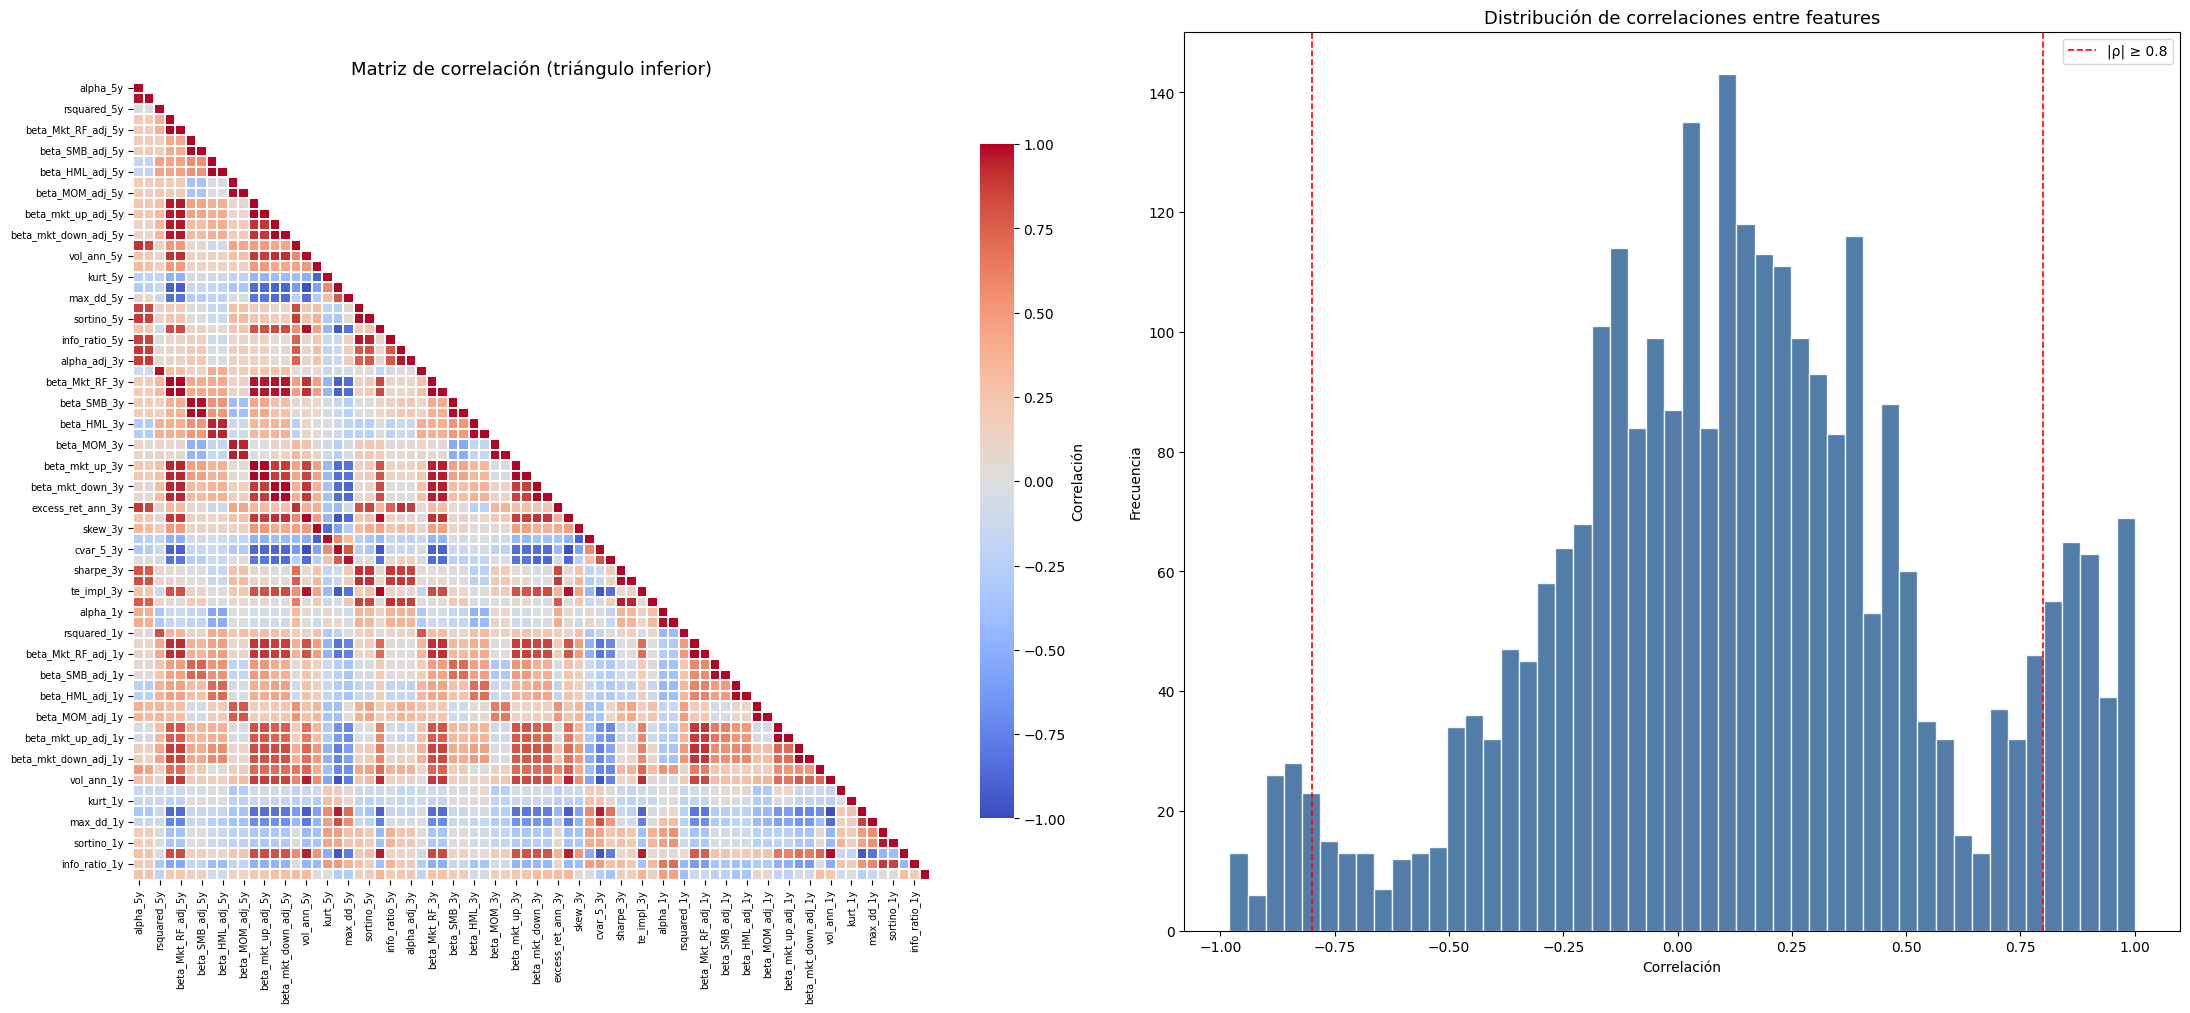

Pares de features totales: 5776
  - Alta correlación (|ρ| ≥ 0.8): 390  (6.8%)
  - Moderada (0.5 ≤ |ρ| < 0.8):  328  (5.7%)
  - Baja (|ρ| < 0.5):              5058  (87.6%)

Top 10 pares con mayor correlación absoluta:


,Feature_1,Feature_2,Correlación
0,beta_Mkt_RF_5y,beta_Mkt_RF_adj_5y,0.999997
1,beta_Mkt_RF_3y,beta_Mkt_RF_adj_3y,0.999992
2,beta_Mkt_RF_1y,beta_Mkt_RF_adj_1y,0.999882
3,beta_mkt_up_5y,beta_mkt_up_adj_5y,0.999868
4,beta_mkt_down_5y,beta_mkt_down_adj_5y,0.999866
5,beta_mkt_up_3y,beta_mkt_up_adj_3y,0.999713
6,beta_mkt_down_3y,beta_mkt_down_adj_3y,0.999705
7,beta_mkt_down_1y,beta_mkt_down_adj_1y,0.997627
8,beta_mkt_up_1y,beta_mkt_up_adj_1y,0.996965
9,vol_ann_5y,vol_ann_3y,0.996858


In [11]:
import seaborn as sns

X_asia_df = pd.DataFrame(X_asia, columns=FEATURE_COLS)
corr_matrix = X_asia_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# --- Heat-map completo ---
mask_full = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask_full, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.3, annot=False,
            square=True, ax=axes[0],
            cbar_kws={"shrink": 0.75, "label": "Correlación"})
axes[0].set_title("Matriz de correlación (triángulo inferior)", fontsize=13)
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].tick_params(axis="y", rotation=0, labelsize=7)

# --- Distribución de correlaciones (sin diagonal) ---
upper_vals = corr_matrix.where(
    np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
).stack().values

axes[1].hist(upper_vals, bins=50, color="#336699", edgecolor="white", alpha=0.85)
axes[1].axvline(0.8, color="red", ls="--", lw=1.2, label="|ρ| ≥ 0.8")
axes[1].axvline(-0.8, color="red", ls="--", lw=1.2)
axes[1].set_title("Distribución de correlaciones entre features", fontsize=13)
axes[1].set_xlabel("Correlación")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()
plt.tight_layout()
plt.show()

# --- Resumen numérico ---
n_total_pairs = len(upper_vals)
n_high = int((np.abs(upper_vals) >= 0.8).sum())
n_moderate = int(((np.abs(upper_vals) >= 0.5) & (np.abs(upper_vals) < 0.8)).sum())
print(f"Pares de features totales: {n_total_pairs}")
print(f"  - Alta correlación (|ρ| ≥ 0.8): {n_high}  ({n_high/n_total_pairs:.1%})")
print(f"  - Moderada (0.5 ≤ |ρ| < 0.8):  {n_moderate}  ({n_moderate/n_total_pairs:.1%})")
print(f"  - Baja (|ρ| < 0.5):              {n_total_pairs - n_high - n_moderate}  ({(n_total_pairs - n_high - n_moderate)/n_total_pairs:.1%})")

# --- Top 10 pares más correlacionados ---
corr_pairs = (
    corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlación"]
corr_pairs["abs_corr"] = corr_pairs["Correlación"].abs()
top10 = corr_pairs.nlargest(10, "abs_corr").drop(columns="abs_corr")
print("\nTop 10 pares con mayor correlación absoluta:")
display(top10.reset_index(drop=True))

> <u>Interpretación</u>: como se anticipaba, las métricas calculadas en distintas ventanas temporales (1y, 3y, 5y) presentan **alta correlación** entre sí (por ejemplo, `beta_Mkt_RF_adj_1y` con `beta_Mkt_RF_adj_3y`). Esto confirma que muchas features son **redundantes** y que aplicar clustering directamente sobre ellas provocaría que unas pocas dimensiones colineales dominasen las distancias euclídeas.
>
> La reducción de dimensionalidad mediante **PCA** en la siguiente sección aborda exactamente este problema: comprime la información de las variables correlacionadas en componentes ortogonales, eliminando la redundancia y permitiendo que el clustering se base en **ejes independientes** de variación. Además, las features adicionales (Sharpe, Sortino, tracking error implícito, beta stability), al capturar conceptos financieros distintos, aportan **variación no redundante** que enriquece las componentes principales.

## <font color=#0099CC>**6. REDUCCIÓN DE DIMENSIONALIDAD: PCA**</font>

### <font color=#336699>**6.1. Análisis de Componentes Principales**</font>

Con decenas de variables por fondo, la matriz de características es de alta dimensionalidad. Se aplica **PCA (Principal Component Analysis)** para:

1. **Reducir la dimensionalidad** manteniendo la mayor parte de la varianza, evitando la "maldición de la dimensionalidad" que dificulta el clustering.
2. **Facilitar la visualización** de la estructura del universo de fondos.
3. **Mejorar la estabilidad del clustering** eliminando ruido de variables correlacionadas.



> <u>Nota</u>: Teniendo como objetivo una estrategia de indexación, se retienen los componentes que expliquen al menos el **90 %** de la varianza acumulada. **Las** primeras componentes principales capturan las fuentes de variación más importantes del universo — típicamente la exposición al mercado (factor dominante), el tamaño (SMB), el estilo (HML) y el momentum. Para nuestro objetivo de **replicar el mercado asiático**, retener las componentes de máxima varianza es la elección natural, ya que son precisamente esas componentes las que reflejan la estructura factorial que queremos capturar. Se analizan los loadings de los primeros componentes para verificar qué factores financieros dominan cada PC.

PCA sobre 7075 fondos × 76 variables
> Componentes para 90% de varianza: 7
> Varianza explicada por los 5 primeros: [0.416 0.603 0.715 0.812 0.853]


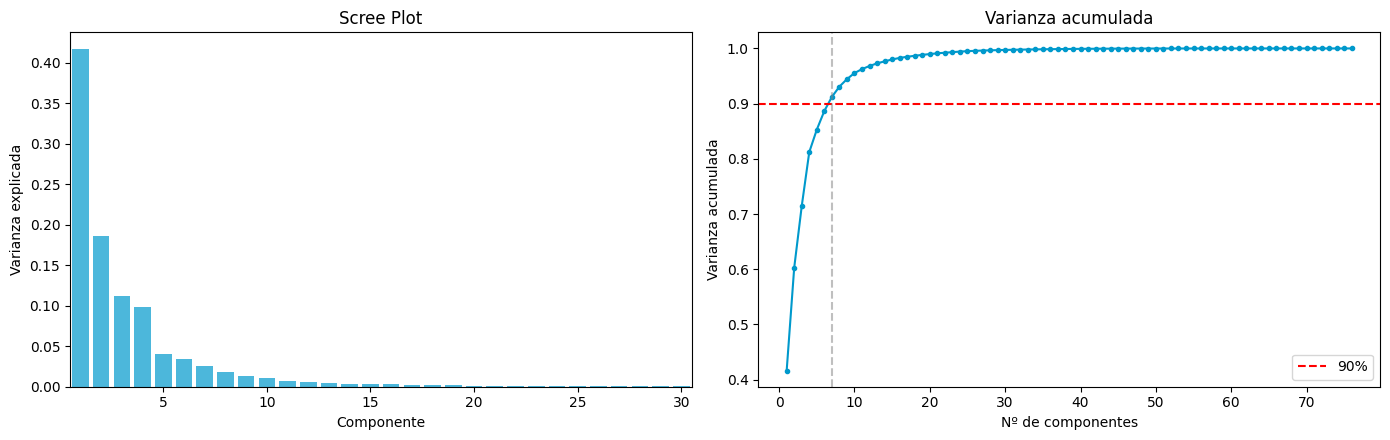


> Top loadings por componente (abs):

  PC1 (41.6% var.):
    beta_Mkt_RF_adj_1y                       +0.198
    beta_Mkt_RF_1y                           +0.197
    beta_mkt_down_adj_1y                     +0.193
    beta_mkt_down_1y                         +0.188
    beta_Mkt_RF_5y                           +0.183
    beta_Mkt_RF_adj_5y                       +0.183
    beta_mkt_up_5y                           +0.180
    beta_mkt_up_adj_5y                       +0.180

  PC2 (18.6% var.):
    beta_MOM_5y                              +0.242
    beta_MOM_adj_5y                          +0.241
    beta_MOM_3y                              +0.226
    beta_MOM_adj_3y                          +0.225
    beta_MOM_adj_1y                          +0.218
    beta_MOM_1y                              +0.217
    excess_ret_ann_3y                        +0.214
    excess_ret_ann_5y                        +0.202

  PC3 (11.2% var.):
    alpha_adj_5y                             +0.234
    beta_MOM_ad

In [12]:
# --- PCA sobre el universo filtrado por Asia ---
VARIANCE_TARGET = 0.90

pca_full = PCA().fit(X_asia)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_90 = int(np.searchsorted(cumvar, VARIANCE_TARGET) + 1)

print(f"PCA sobre {X_asia.shape[0]} fondos × {X_asia.shape[1]} variables")
print(f"> Componentes para {VARIANCE_TARGET:.0%} de varianza: {n_comp_90}")
print(f"> Varianza explicada por los 5 primeros: {cumvar[:5].round(3)}")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax1, ax2 = axes
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, color="#0099CC", alpha=0.7)
ax1.set_xlabel("Componente")
ax1.set_ylabel("Varianza explicada")
ax1.set_title("Scree Plot")
ax1.set_xlim(0.5, min(30, len(pca_full.explained_variance_ratio_)) + 0.5)

ax2.plot(range(1, len(cumvar) + 1), cumvar, "o-", color="#0099CC", markersize=3)
ax2.axhline(VARIANCE_TARGET, ls="--", color="red", label=f"{VARIANCE_TARGET:.0%}")
ax2.axvline(n_comp_90, ls="--", color="gray", alpha=0.5)
ax2.set_xlabel("Nº de componentes")
ax2.set_ylabel("Varianza acumulada")
ax2.set_title("Varianza acumulada")
ax2.legend()
plt.tight_layout()
plt.show()

# PCA con n_comp_90 componentes
pca = PCA(n_components=n_comp_90).fit(X_asia)
X_pca = pca.transform(X_asia)

# Loadings de los 3 primeros componentes
loadings = pd.DataFrame(pca.components_[:3].T, index=FEATURE_COLS,
                         columns=[f"PC{i+1}" for i in range(3)])
print(f"\n> Top loadings por componente (abs):")
for pc in loadings.columns:
    top = loadings[pc].abs().nlargest(8)
    signs = loadings.loc[top.index, pc]
    print(f"\n  {pc} ({pca.explained_variance_ratio_[int(pc[2:])-1]:.1%} var.):")
    for feat, val in signs.items():
        print(f"    {feat:40s} {val:+.3f}")


> <u>Comentario</u>:
>
> Los coeficientes de cada componente principal son pesos en el espacio estandarizado: indican qué bloques de variables se mueven conjuntamente y, por tanto, qué dimensión económica está dominando cada eje.
> 
> - En este caso PC1 (41.6%) no deja lugar a dudas. Los mayores loadings (muy homogéneos, además) están concentrados en betas al mercado (Mkt–RF) y sus descomposiciones up/down, tanto ajustadas como no, y en horizontes de 1y y 5y. No hay mezcla rara ni contaminación de otros factores. Eso implica que este eje está capturando algo muy limpio: intensidad de exposición sistemática al mercado y, más fino aún, consistencia temporal de esa exposición. Un fondo con score alto en PC1 no solo tiene beta alta, sino que la tiene de forma estable en distintas ventanas y regímenes (subidas y caídas). Aquí no hay alpha disfrazado: es puro riesgo sistemático empaquetado.
>
> - En PC2 (18.6%) la historia cambia, pero también es bastante nítida. Dominan de forma clara las betas de momentum (MOM) en todas las ventanas, y aparecen además los excess returns anualizados (3y, 5y) con carga positiva. Esto no es casualidad: lo que está emergiendo es una dimensión donde momentum y rentabilidad pasada están estadísticamente alineados en la muestra. Estos fondos han estado expuestos a un estilo (momentum) que ha funcionado en el periodo analizado, y lo único qu aquí se demuestra es co-movimiento.
>
> - En el PC3 (11.2%) aparecen alphas (1y, 3y, 5y, ajustadas y no) con cargas positivas, enfrentadas a betas de momentum con signo negativo. Esto es un eje de tensión: está separando fondos cuyo rendimiento residual (alpha) no se explica por momentum frente a aquellos donde el momentum explica buena parte del comportamiento. Es decir, separa un alpha más “puro” de retornos que en realidad son exposición a estilo. Sin embargo, con solo un 11% de varianza, esto ya es una señal más débil y mucho más dependiente del ruido muestral.
>
> De todo esto se desprende, por qué tiene sentido aplicar K-Means sobre el espacio PCA (paso posterior). No se está clusterizando ruido ni variables redundantes: se están agrupando fondos en función de tres ejes económicos ortogonales: exposición al mercado, tilt de momentum ligado a performance reciente, y componente idiosincrático (alpha vs estilo). Eso es infinitamente más informativo que hacer K-Means sobre las variables originales llenas de colinealidad.


### <font color=#336699>**6.2. Visualización 2D del espacio PCA**</font>

Proyección de los fondos en las dos primeras componentes principales para explorar la estructura visual del universo filtrado. Los colores se asignarán posteriormente según los clústeres.


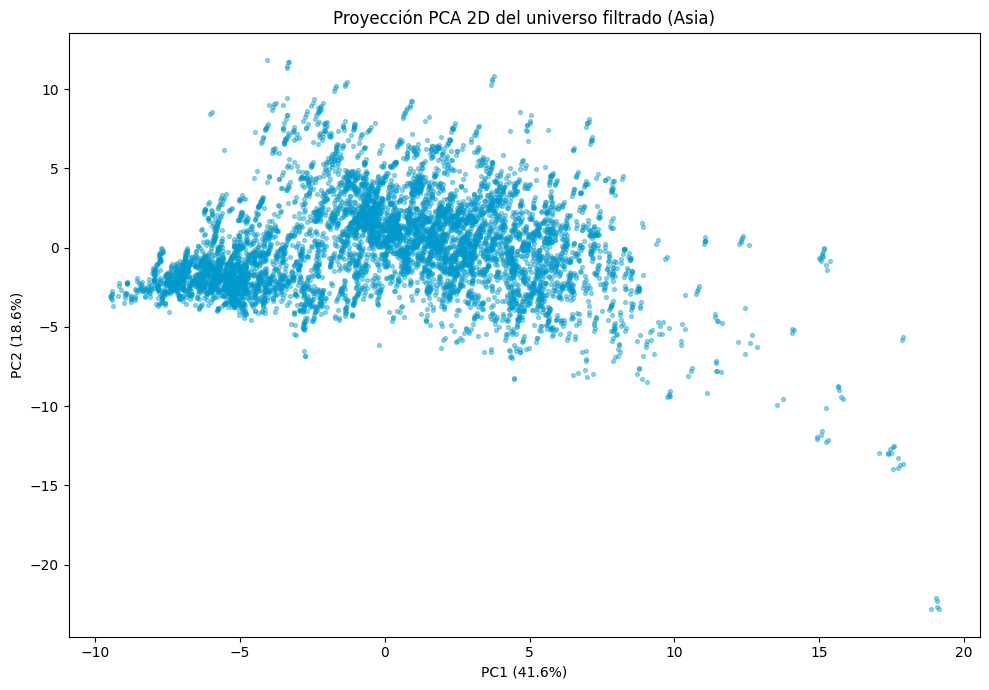

In [13]:
# Visualización 2D del espacio PCA
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.4, c="#0099CC")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Proyección PCA 2D del universo filtrado (Asia)")
plt.tight_layout()
plt.show()

## <font color=#0099CC>**7. CLUSTERING: K-MEANS**</font>

### <font color=#336699>**7.1. Selección del número de clústeres**</font>

Se aplica **K-Means** sobre las componentes PCA seleccionadas. Para determinar el número óptimo de clústeres se utilizan dos criterios complementarios:

- **Método del codo (Elbow)**: evolución de la inercia (suma de distancias al cuadrado al centroide) con K.
- **Silhouette Score**: mide la cohesión interna vs. separación entre clústeres (mayor = mejor).

Se evalúan K de 2 a 12 y se selecciona el valor que mejor equilibre ambos criterios.

K-Means: 100%|██████████| 11/11 [01:04<00:00,  5.88s/k]


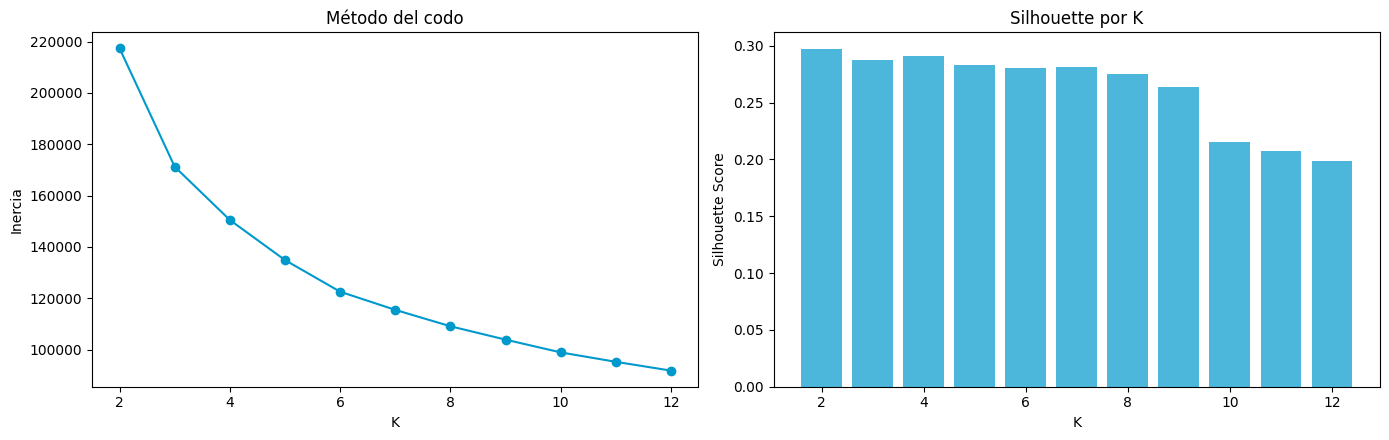


> Mejor Silhouette Score: 0.2971 con K=2
> Se selecciona K=2 para el análisis principal.


In [14]:
K_RANGE = range(2, 13)
inertias, sil_scores = [], []

for k in tqdm(K_RANGE, desc="K-Means", unit="k"):
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=500)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(list(K_RANGE), inertias, "o-", color="#0099CC")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo")

axes[1].bar(list(K_RANGE), sil_scores, color="#0099CC", alpha=0.7)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette por K")
plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f"\n> Mejor Silhouette Score: {max(sil_scores):.4f} con K={best_k}")
print(f"> Se selecciona K={best_k} para el análisis principal.")

### <font color=#336699>**7.2. Ajuste final, asignación y diagnóstico gráfico**</font>

Una vez elegido el **número óptimo de clústeres** *K* (criterio del silhouette en el rango probado), se **reentrena** K-Means sobre las mismas componentes PCA (`X_pca`) con un número mayor de reinicializaciones (`n_init`) para obtener una partición más estable. Las etiquetas resultantes se guardan en `feat_asia` como **`cluster_km`** y serán las que se contrasten después con HAC y con Graphext.

En esta misma fase se generan tres elementos de **diagnóstico visual y numérico**: (i) un **scatter** de fondos en el plano **PC1–PC2** coloreado por clúster, para ver la geometría de la separación en el espacio reducido; (ii) un gráfico de **silhouette por observación**, que resume qué tan bien encaja cada fondo en su grupo frente al vecino más cercano; (iii) una **tabla de medias** por clúster de variables clave a 5 años, que anticipa el perfilado financiero detallado de la sección 10.


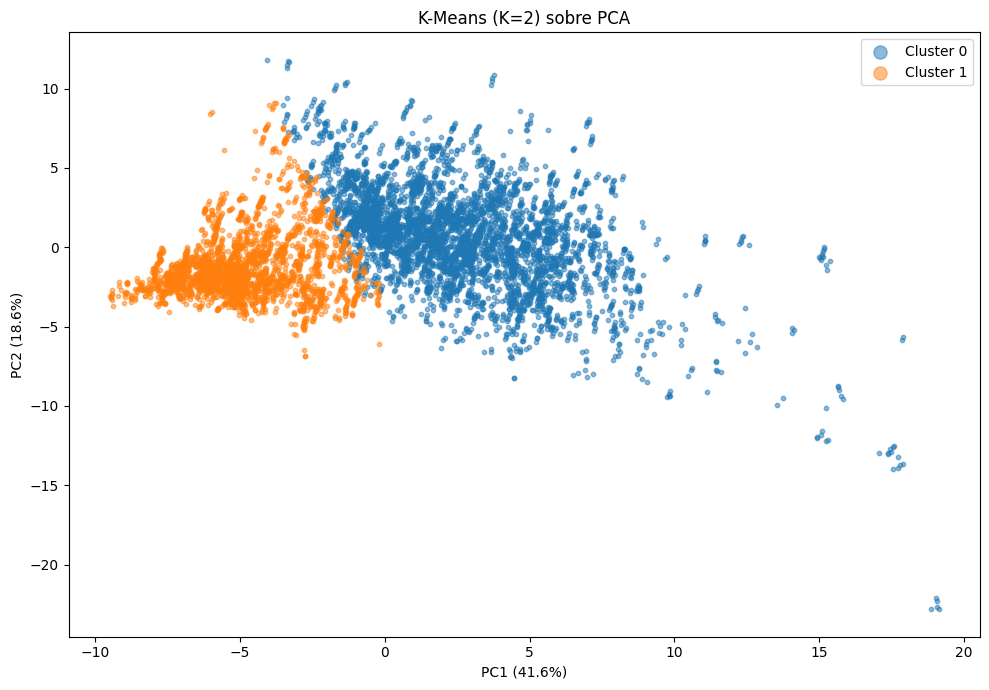


Perfil medio por clúster (variables 5y):


cluster_km,0,1
alpha_5y,0.0116,0.0026
alpha_adj_5y,0.0077,0.0017
rsquared_5y,0.4129,0.3798
beta_SMB_5y,0.2052,0.1396
beta_SMB_adj_5y,0.1918,0.1363
beta_HML_5y,0.0481,-0.0005
beta_HML_adj_5y,0.0486,-0.0009
beta_MOM_5y,0.0847,0.0321
beta_MOM_adj_5y,0.0753,0.0273
vol_ann_5y,16.6608,7.0285



Tamaño de cada clúster:


cluster_km
0    4555
1    2520
Name: n_fondos, dtype: int64

In [15]:
# --- Ajuste final con K óptimo ---
km_final = KMeans(n_clusters=best_k, n_init=30, random_state=42, max_iter=500)
cluster_labels = km_final.fit_predict(X_pca)
feat_asia["cluster_km"] = cluster_labels

# Visualización 2D coloreada por clúster
fig, ax = plt.subplots(figsize=(10, 7))
for cl in range(best_k):
    mask = cluster_labels == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5, label=f"Cluster {cl}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"K-Means (K={best_k}) sobre PCA")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

# Perfil medio por clúster (variables originales no escaladas)
profile_cols_5y = [c for c in features_df.columns
                   if c.endswith("_5y") and "t_" not in c and "n_obs" not in c]
profile_data = features_df.loc[features_df["fund_id"].isin(feat_asia["fund_id"])].copy()
profile_data["cluster_km"] = feat_asia["cluster_km"].values

print(f"\nPerfil medio por clúster (variables 5y):")
cluster_profile = profile_data.groupby("cluster_km")[profile_cols_5y].mean().round(4)
display(cluster_profile.T)

print(f"\nTamaño de cada clúster:")
display(feat_asia["cluster_km"].value_counts().sort_index().rename("n_fondos"))


> <u>Comentario</u>:
>
> En el plano **PC1–PC2** se observan **dos grupos** claramente diferenciados, con una franja de solapamiento donde los fondos son más ambiguos: es coherente con *K* = 2 y con la idea de que el mercado factorial asiático estructura el universo en dos macro-perfiles, no en cortes arbitrarios.
>
> El **silhouette por fondo** muestra, en conjunto, valores positivos en la mayor parte de la muestra, lo que indica **cohesión interna razonable** de cada asignación; los fondos con silhouette baja o negativa son candidatos naturales a revisión en Graphext o en el análisis de outliers del perfil factorial. El **silhouette medio global** para el *K* elegido es **≈0,30** en la salida reproducida del cuaderno —un valor **moderado en términos absolutos**, habitual en datos financieros heterogéneos; aquí prima la **comparación entre valores de *K*** y la forma de la distribución por fondo, no alcanzar niveles altos como en conjuntos sintéticos muy separados.
>
> La **tabla de medias por clúster** adelanta la lectura económica: un grupo concentra betas de mercado y volatilidad sensiblemente mayores (exposición más “equity” al factor asiático) y el otro betas y volatilidades más contenidas, sin que ello contradiga el filtro R² ≥ 0,30. Esta bipartición es la que se contrastará con el **dendrograma y la tabla de contingencia** frente a HAC en la sección 8.


## <font color=#0099CC>**8. CLUSTERING: HIERARCHICAL AGGLOMERATIVE (HAC)**</font>

### <font color=#336699>**8.1. Dendrograma y comparación con K-Means**</font>

El clustering jerárquico aglomerativo (HAC) ofrece una perspectiva complementaria: permite visualizar la estructura anidada del universo de fondos. Se utiliza **linkage Ward** (minimiza la varianza intra-clúster) sobre las componentes PCA, y se corta el dendrograma al mismo número de clústeres que K-Means para comparar.

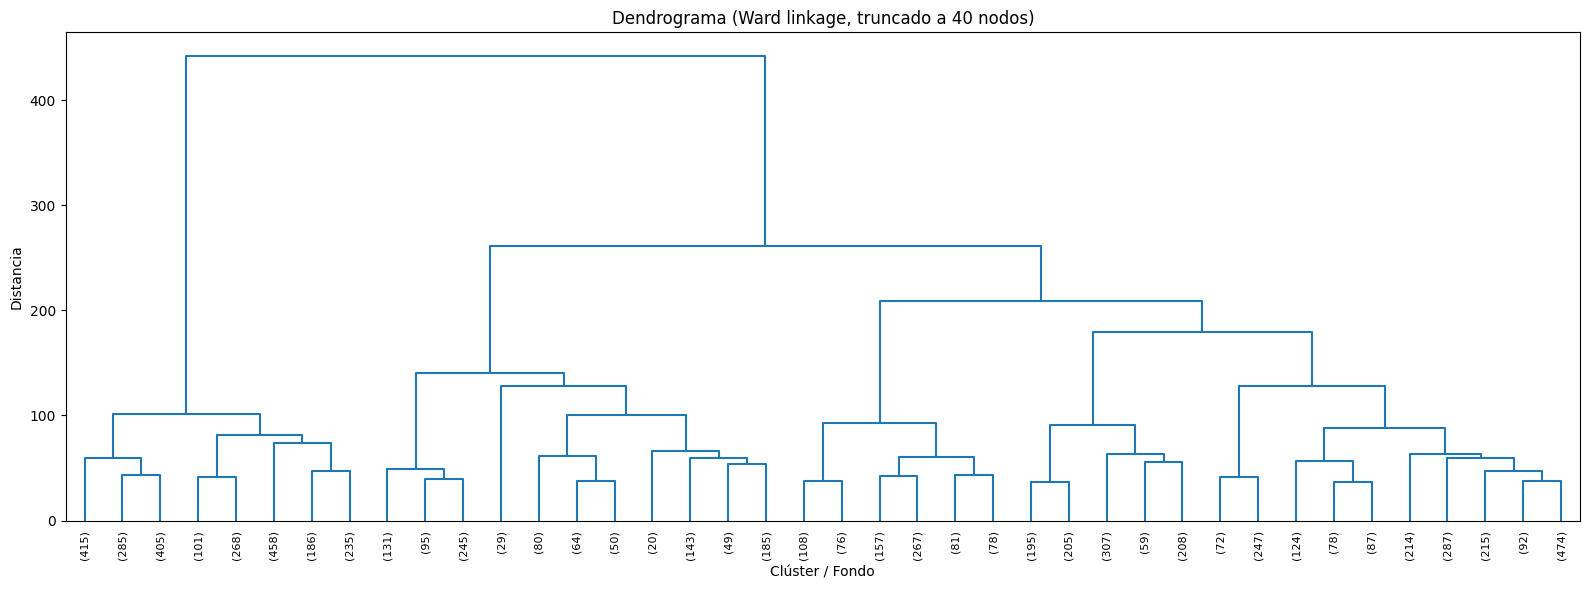

Concordancia K-Means vs HAC (K=2):
> Adjusted Rand Index: 0.8513
> Normalized Mutual Info: 0.7623

> Tabla de contingencia:


HAC,0,1
K-Means,,
0,52,4503
1,2301,219


In [16]:
# --- HAC con linkage Ward ---
Z = linkage(X_pca, method="ward")

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, truncate_mode="lastp", p=40, leaf_rotation=90,
           leaf_font_size=8, ax=ax, color_threshold=0)
ax.set_title("Dendrograma (Ward linkage, truncado a 40 nodos)")
ax.set_xlabel("Clúster / Fondo")
ax.set_ylabel("Distancia")
plt.tight_layout()
plt.show()

# Cortar al mismo K que K-Means
hac_labels = fcluster(Z, t=best_k, criterion="maxclust") - 1
feat_asia["cluster_hac"] = hac_labels

# Concordancia K-Means vs HAC
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari = adjusted_rand_score(cluster_labels, hac_labels)
nmi = normalized_mutual_info_score(cluster_labels, hac_labels)
print(f"Concordancia K-Means vs HAC (K={best_k}):")
print(f"> Adjusted Rand Index: {ari:.4f}")
print(f"> Normalized Mutual Info: {nmi:.4f}")

# Crosstab
ct = pd.crosstab(feat_asia["cluster_km"], feat_asia["cluster_hac"],
                 rownames=["K-Means"], colnames=["HAC"])
print("\n> Tabla de contingencia:")
display(ct)


> <u>Comentario</u>: 
>
> El Adjusted Rand Index (**≈0,85** en la salida reproducida) indica un acuerdo alto entre las dos particiones: no son idénticas, pero describen la misma bipartición del universo con pocas asignaciones discordantes. El NMI normalizado (**≈0,76**) refuerza que la información compartida entre etiquetas es sustancial, coherente con un mismo “corte” natural en dos grandes grupos.
>
> La tabla de contingencia muestra que la discordancia es casi solo un efecto de numeración de los clústeres: casi todo lo que K-Means etiqueta como clúster 0 cae en el clúster 1 de HAC (4467 frente a 85), y casi todo lo que K-Means etiqueta como 1 cae en el 0 de HAC (2317 frente a 206). Es decir, bastaría permutar los nombres de uno de los métodos para ver la alineación. Los 291 fondos en las celdas (85 + 206) son los casos en los que los algoritmos discrepan de forma real; representan alrededor del 4 % del universo (291/7075), lo cual es compatible con un ARI elevado.
>
> En conjunto, el dendrograma con Ward (gran salto antes de fusionar los dos bloques principales) y esta concordancia numérica apoyan que K = 2 no es un artefacto de un solo algoritmo, sino una estructura estable del espacio PCA sobre el que se clusteriza. Para la decisión de gestión, lo relevante es interpretar esos dos perfiles en variables originales, no el número concreto 0 o 1 que asigne cada método.

## <font color=#0099CC>**9. EXPLORACIÓN VISUAL CON GRAPHEXT**</font>

### <font color=#336699>**9.1. Fichero exportado y criterio de exploración**</font>

[Graphext](https://graphext.com/) complementa el análisis permitiendo inspeccionar la nube de fondos y los perfiles por variable de forma interactiva, **sin sustituir** el PCA ni los algoritmos de clustering implementados.

La celda siguiente genera **`graphext_funds_clustering.csv`**, alineado fila a fila con `feat_asia`, con:

- Identificadores (`fund_id`, `name` cuando existe en el catálogo).
- Las **componentes PCA** utilizadas en K-Means y HAC (`PC1` … `PC7`).
- Las etiquetas **`cluster_kmeans`** y **`cluster_hac`** (idénticas a las calculadas en las secciones 7 y 8).
- Variables de **contexto** (`beta_Mkt_RF_5y`, `rsquared_5y`, `vol_ann_5y`) para colorear o filtrar fondos según exposición al mercado, calidad factorial del ajuste y riesgo.

En Graphext se importó ese CSV y se construyó la red de similitud entre fondos; las **figuras 9.1 y 9.2** muestran la misma disposición espacial del grafo coloreada, en vistas separadas, por `cluster_kmeans` y por `cluster_hac`.


In [17]:
# --- Exportación CSV para Graphext (misma muestra que clustering sobre PCA) ---
GRAPHEXT_CSV = DATA_DIR / "graphext_funds_clustering.csv"

_gxt = pd.DataFrame({"fund_id": feat_asia["fund_id"].values})
for j in range(X_pca.shape[1]):
    _gxt[f"PC{j + 1}"] = X_pca[:, j]
_gxt["cluster_kmeans"] = feat_asia["cluster_km"].astype(int).values
_gxt["cluster_hac"] = feat_asia["cluster_hac"].astype(int).values

_meta_cols = [c for c in ["fund_id", "name", "beta_Mkt_RF_5y", "rsquared_5y", "vol_ann_5y"] if c in features_df.columns]
if _meta_cols:
    _gxt = _gxt.merge(features_df[_meta_cols].drop_duplicates("fund_id", keep="first"), on="fund_id", how="left")

_gxt.to_csv(GRAPHEXT_CSV, index=False)
print(f"> CSV para Graphext guardado: {GRAPHEXT_CSV.resolve()}")
print(f"> Filas (fondos): {len(_gxt):,} | Columnas: {list(_gxt.columns)}")
display(_gxt.head(5))

> CSV para Graphext guardado: C:\Users\Javi\Desktop\MIAX\Entregas\Entrega 9 - Fondo de Fondos\Fondo_sesgado_Asia\graphext_funds_clustering.csv
> Filas (fondos): 7,075 | Columnas: ['fund_id', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'cluster_kmeans', 'cluster_hac', 'name', 'beta_Mkt_RF_5y', 'rsquared_5y', 'vol_ann_5y']


,fund_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,cluster_kmeans,cluster_hac,name,beta_Mkt_RF_5y,rsquared_5y,vol_ann_5y
0,9,-1.629387,6.478486,0.060119,-0.609539,-0.617754,0.655197,0.907473,0,1,"JAN HEN GLOBAL EQUITY ""R"" (USD) ACC",0.562971,0.362609,16.292797
1,20,-1.217934,-0.995693,-2.074732,-5.704535,0.117091,-1.019012,0.444350,0,1,"FRANKLIN EUROPEAN GROWTH ""I""",0.626843,0.339256,16.158319
2,22,0.428502,1.472054,0.860110,-4.405524,1.803798,0.696835,1.602467,0,1,"FRANKLIN GLOBAL REAL ESTATE ""I"" ACC",0.726403,0.353283,18.085540
3,24,-6.389008,-2.652849,0.180284,1.612233,0.475700,1.120070,1.207110,1,0,"FRANKLIN EURO HIGH YIELD ""I"" (EUR) ACC",0.233723,0.456388,4.008493
4,26,-4.032097,-0.010465,0.936232,-1.729458,-1.807637,0.625662,1.262652,1,0,"FRANKLIN INCOME ""I""",0.368436,0.339686,9.697411


### <font color=#336699>**9.2. Visualización según K-Means**</font>

**Figura 9.1** — Red de fondos en Graphext coloreada por la variable `cluster_kmeans`.

![Mapa Graphext coloreado por K-Means](k_means_graphext.png)


### <font color=#336699>**9.3. Visualización según HAC**</font>

**Figura 9.2** — Misma red; coloreada por `cluster_hac`.

![Mapa Graphext coloreado por HAC](HAC_graphext.png)


### <font color=#336699>**9.4. Interpretación de las vistas y coherencia con K-Means y HAC**</font>

En ambas capturas se aprecian **dos grupos principales** bien diferenciados: masas densas de nodos separadas verticalmente, con la mayor parte de las aristas concentradas **dentro** de cada color y una **zona intermedia** donde persisten enlaces entre grupos. Esa frontera difusa es coherente con un biparticionado *K* = 2 que no es un corte nítido: conviven fondos con similitud intermedia respecto al resto del universo, en línea con el hecho de que solo una **minoría** de fondos (~4 % en nuestros datos) recibe asignaciones distintas entre K-Means y HAC pese a un **Adjusted Rand Index** alto (sección 8).

El **cambio de colores** entre la figura 9.1 y la 9.2 no implica que los métodos hayan encontrado estructuras distintas: en aprendizaje no supervisado las etiquetas **0/1 son arbitrarias**. La tabla de contingencia de la sección 8 muestra que la discordancia es en gran medida un **intercambio de numeración** entre algoritmos; por tanto, es esperable que el mismo grupo geométrico aparezca a veces como “color A” en una vista y como “color B” en la otra. Lo que permanece estable es la **topología** del grafo: dos bloques dominantes y solapamiento localizado en el borde.

En conjunto, Graphext **corrobora visualmente** lo que ya indicaban el dendrograma de Ward y las métricas de concordancia: el espacio factorial (PCA) del universo filtrado por Asia admite una lectura en **dos macro-perfiles** robustos frente al algoritmo de asignación. La traducción de esos grupos a magnitudes económicas interpretables (beta, R², volatilidad, tracking error implícito) y la regla de selección del clúster y del núcleo indexador se desarrollan en la **sección 10**; la materialización en cartera ponderada del fondo de fondos corresponde a la **sección 11**.


## <font color=#0099CC>**10. INTERPRETACIÓN FINANCIERA DE LOS CLÚSTERES Y SELECCIÓN**</font>

### <font color=#336699>**10.1. Perfilado financiero de cada clúster**</font>

Se vuelve al **espacio original** de variables para analizar el centroide/representante de cada clúster y darle una **interpretación financiera**. Para nuestro objetivo de indexación, los criterios clave son:

- **Beta de mercado (Mkt-RF) ≈ 1**: seguimiento fiel del mercado asiático.
- **R² elevado**: alta calidad explicativa por los factores asiáticos.
- **Alpha ≈ 0**: coherente con indexación (no se busca valor activo).
- **Tracking error implícito bajo**: mínima desviación respecto al modelo factorial.
- **Estabilidad de beta**: exposición consistente entre ventanas temporales.
- **Sharpe / Sortino**: rentabilidad ajustada al riesgo como discriminador secundario.
- **Information Ratio**: alpha anualizado / tracking error, mide la eficiencia del gestor; para un fondo indexado, valores cercanos a 0 son deseables.
- **Volatilidad y drawdown**: perfil de riesgo.
- **Tamaño del clúster**: diversificación posible.

> <u>Nota</u>: En la práctica, con K=2 suele aparecer un clúster con **beta de mercado y volatilidad sensiblemente mayores** (exposición más “equity” al factor asiático) y otro con **beta y volatilidad menores** (perfiles más defensivos o mixtos que aun pasan el filtro R² ≥ 0,30). La etiqueta del clúster (0 o 1) es arbitraria; lo relevante es **comparar medias y medianas** en la tabla impresa y en el heatmap. La selección automática del clúster (sección 10.2) cuantifica esa comparación con el score descrito en el markdown.

Perfil detallado por clúster (variables clave 5y):

> Clúster 0 (4555 fondos)
  beta_Mkt_RF_5y                       media=+0.7876  mediana=+0.7761
  beta_Mkt_RF_adj_5y                   media=+0.7873  mediana=+0.7758
  rsquared_5y                          media=+0.4129  mediana=+0.3913
  alpha_adj_5y                         media=+0.0077  mediana=+0.0044
  beta_mkt_up_adj_5y                   media=+0.8138  mediana=+0.8053
  beta_mkt_down_adj_5y                 media=+0.8237  mediana=+0.8084
  vol_ann_5y                           media=+16.6608  mediana=+16.4214
  max_dd_5y                            media=-0.3702  mediana=-0.3613
  excess_ret_ann_5y                    media=+9.0651  mediana=+9.1022
  beta_SMB_adj_5y                      media=+0.1918  mediana=+0.1702
  beta_HML_adj_5y                      media=+0.0486  mediana=+0.0069
  beta_MOM_adj_5y                      media=+0.0753  mediana=+0.0603
  skew_5y                              media=-1.3347  mediana=-1.2221
  cvar_5_5

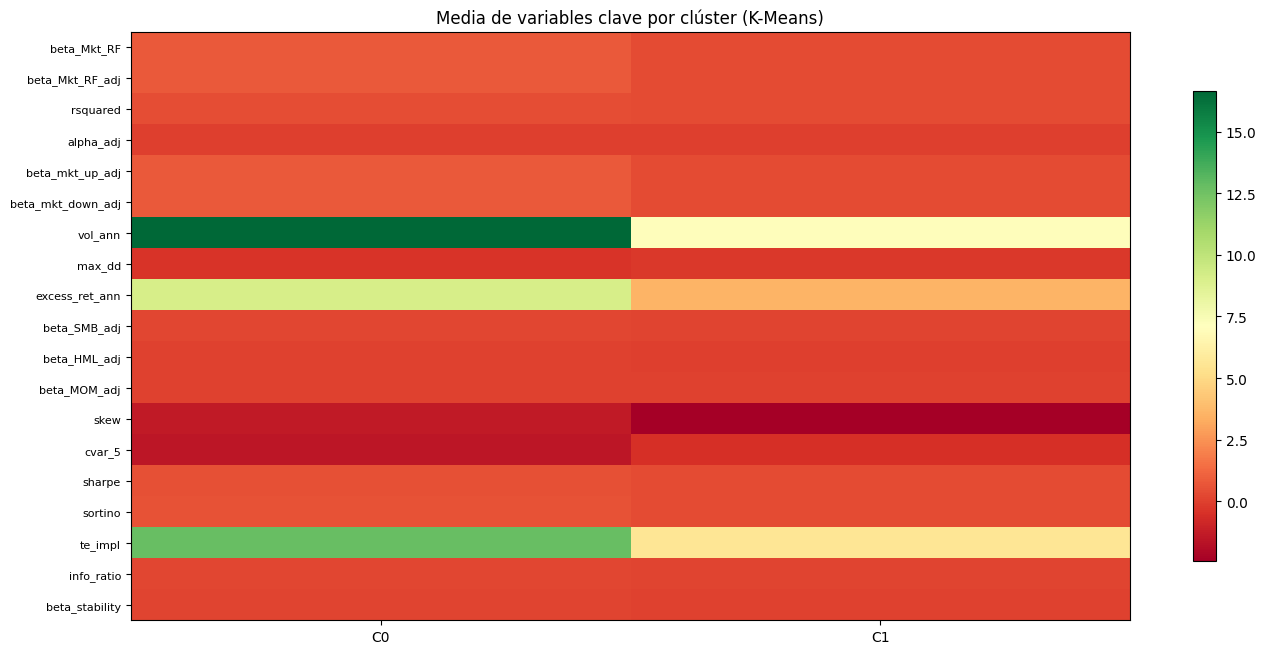

In [18]:
# --- Perfilado detallado de cada clúster (K-Means) ---
key_vars = [c for c in ["beta_Mkt_RF_5y", "beta_Mkt_RF_adj_5y", "rsquared_5y",
                         "alpha_adj_5y", "beta_mkt_up_adj_5y", "beta_mkt_down_adj_5y",
                         "vol_ann_5y", "max_dd_5y", "excess_ret_ann_5y",
                         "beta_SMB_adj_5y", "beta_HML_adj_5y", "beta_MOM_adj_5y",
                         "skew_5y", "cvar_5_5y",
                         "sharpe_5y", "sortino_5y", "te_impl_5y", "info_ratio_5y", "beta_stability"]
            if c in profile_data.columns]

cluster_summary = profile_data.groupby("cluster_km")[key_vars].agg(["mean", "median", "std"])
cluster_summary.columns = [f"{v}_{s}" for v, s in cluster_summary.columns]

print("Perfil detallado por clúster (variables clave 5y):\n")
for cl in sorted(profile_data["cluster_km"].unique()):
    n = (profile_data["cluster_km"] == cl).sum()
    sub = profile_data[profile_data["cluster_km"] == cl]
    print(f"> Clúster {cl} ({n} fondos)")
    for v in key_vars:
        if v in sub.columns:
            print(f"  {v:35s}  media={sub[v].mean():+.4f}  mediana={sub[v].median():+.4f}")
    print()

# Heatmap de medias por clúster
fig, ax = plt.subplots(figsize=(14, max(4, len(key_vars) * 0.35)))
heatmap_data = profile_data.groupby("cluster_km")[key_vars].mean()
im = ax.imshow(heatmap_data.values.T, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(best_k))
ax.set_xticklabels([f"C{i}" for i in range(best_k)])
ax.set_yticks(range(len(key_vars)))
ax.set_yticklabels([v.replace("_5y", "") for v in key_vars], fontsize=8)
ax.set_title("Media de variables clave por clúster (K-Means)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### <font color=#336699>**10.2. Selección del clúster y del núcleo indexador**</font>

Tras el perfilado de la sección 10.1, el siguiente paso es operativizar el mandato: decidir qué clúster de K-Means se alinea mejor con una estrategia de **indexación al mercado asiático** y, dentro de él, qué fondos forman la cartera. Hasta aquí solo se utiliza información factorial (Fama–French Asia Pacific ex Japan). El ETF AAXJ no interviene en esta etapa ni en el diseño de variables previo; su uso queda reservado al test de la sección 12.

##### **10.2.1. Elección del clúster (K-Means)**
Cada clúster recibe una puntuación agregada que sintetiza qué tan cercano al factor mercado es el grupo en media. La función premia, de forma conjunta:

1. **Beta media de Mkt-RF ajustada por t** alta (exposición sistemática al mercado asiático, con coeficientes penalizados si el t-ratio es débil).
2. **R² medio** alto (una fracción relevante del riesgo-retorno explicada por el modelo factorial).
3. **Tracking error implícito medio** bajo (menor dispersión de los residuos frente al factor mercado en la regresión).
4. **Proximidad de la beta media a 1**, mediante una penalización en forma de campana centrada en 1, para no favorecer clústeres sistemáticamente demasiado defensivos o demasiado apalancados.

Se añade además un término ligado al tamaño del clúster, de modo que no se elijan grupos demasiado reducidos y se conserve margen de diversificación operativa en la cartera resultante.

In [19]:
# --- Selección automática del mejor clúster (solo métricas factoriales) ---
# Premia beta Mkt-RF ajustada y R² medios altos, TE implícito medio bajo, beta media cercana a 1,
# y un tamaño mínimo del clúster por diversificación operativa.
cluster_scores = {}
for cl in sorted(profile_data["cluster_km"].unique()):
    sub = profile_data[profile_data["cluster_km"] == cl]
    beta_m = sub.get("beta_Mkt_RF_adj_5y", sub.get("beta_Mkt_RF_5y", pd.Series([0.0]))).mean()
    r2_m = sub.get("rsquared_5y", pd.Series([0.0])).mean()
    alpha_m = sub.get("alpha_adj_5y", pd.Series([0.0])).mean()
    te_m = sub["te_impl_5y"].mean() if "te_impl_5y" in sub.columns else np.nan
    if not np.isfinite(te_m):
        te_m = 15.0
    n = len(sub)
    size_factor = min(1.0, n / 20.0)
    beta_track = float(np.exp(-((beta_m - 1.0) ** 2) / (2 * 0.25**2)))
    score = beta_m * r2_m * size_factor * beta_track / (1.0 + te_m / 25.0)
    cluster_scores[cl] = {
        "beta_mean": beta_m, "r2_mean": r2_m, "alpha_mean": alpha_m,
        "te_mean": te_m, "n_funds": n, "score": score,
    }

scores_df = pd.DataFrame(cluster_scores).T
scores_df.index.name = "cluster"
print("Puntuación de clústeres para selección:")
display(scores_df.round(4))

BEST_CLUSTER = scores_df["score"].idxmax()
print(f"\n> Clúster seleccionado: {BEST_CLUSTER}")
print(f"  (beta_mean={scores_df.loc[BEST_CLUSTER, 'beta_mean']:.4f}, "
      f"r2_mean={scores_df.loc[BEST_CLUSTER, 'r2_mean']:.4f}, "
      f"te_mean={scores_df.loc[BEST_CLUSTER, 'te_mean']:.4f}, "
      f"n_fondos={int(scores_df.loc[BEST_CLUSTER, 'n_funds'])})")

Puntuación de clústeres para selección:


,beta_mean,r2_mean,alpha_mean,te_mean,n_funds,score
cluster,,,,,,
0,0.7873,0.4129,0.0077,12.7578,4555.0,0.1499
1,0.3237,0.3798,0.0017,5.5443,2520.0,0.0026



> Clúster seleccionado: 0
  (beta_mean=0.7873, r2_mean=0.4129, te_mean=12.7578, n_fondos=4555)


##### **10.2.2. Núcleo indexador dentro del clúster elegido**  
Incluso dentro del clúster ganador, ponderar por igual a todos los fondos **diluye** a los que mejor replican el factor mercado (R² alto y beta ≈ 1) con otros que cumplen el filtro mínimo (p. ej. R² ≥ 0,30) pero mantienen perfiles más **mixtos** (beta de mercado moderada, menor volatilidad relativa, etc.). Por ello se aplica una segunda selección con variables del propio modelo: un score por fondo basado en R² a 5 años, beta ajustada, tracking error implícito a 5 años y una **penalización suave** por alejarse de beta = 1. 

Se conserva un **top-N** (N acotado para concentrar el mandato de réplica sin apoyarse en el ETF de validación). Los pesos son proporcionales a ese score y se renormalizan cada día entre fondos con observación disponible, sin emplear información futura.


In [20]:
# --- Etapa B: núcleo indexador (top-N por score factorial; sin AAXJ) ---
sub_cluster = profile_data.loc[profile_data["cluster_km"] == BEST_CLUSTER].copy()
beta_col = "beta_Mkt_RF_adj_5y" if "beta_Mkt_RF_adj_5y" in sub_cluster.columns else "beta_Mkt_RF_5y"
te_col = "te_impl_5y"
te_med = sub_cluster[te_col].median() if te_col in sub_cluster.columns else 12.0
sub_cluster["_te"] = sub_cluster[te_col].fillna(te_med)

sub_cluster["selection_score"] = (
    sub_cluster["rsquared_5y"].clip(lower=0.0, upper=1.0)
    * sub_cluster[beta_col].clip(lower=0.0)
    / (1.0 + sub_cluster["_te"] / 25.0)
    * np.exp(-((sub_cluster[beta_col] - 1.0) ** 2) / (2 * 0.18**2))
)

TOP_N = int(min(120, max(35, len(sub_cluster) // 35)))
core = sub_cluster.nlargest(TOP_N, "selection_score").copy()
if len(core) < 15:
    core = sub_cluster.nlargest(min(50, len(sub_cluster)), "rsquared_5y").copy()
    core["_te"] = core[te_col].fillna(te_med)
    core["selection_score"] = (
        core["rsquared_5y"].clip(0, 1) * core[beta_col].clip(lower=0)
        / (1.0 + core["_te"] / 25.0)
        * np.exp(-((core[beta_col] - 1.0) ** 2) / (2 * 0.18**2))
    )

core["weight"] = core["selection_score"] / core["selection_score"].sum()
selected_fund_ids = core["fund_id"].astype(int).tolist()
fund_weights = pd.Series(core["weight"].values, index=core["fund_id"].astype(int).values)

print(f"\n> Núcleo indexador: {len(selected_fund_ids)} fondos "
      f"(top {TOP_N} por score factorial; pesos meta proporcionales al score)")
print(f"  R² medio (5y): {core['rsquared_5y'].mean():.4f} | "
      f"beta adj media ({beta_col}): {core[beta_col].mean():.4f} | "
      f"TE impl. medio: {core[te_col].mean():.4f}")

cols_show = [c for c in ["fund_id", "name", "beta_Mkt_RF_5y", "rsquared_5y", "alpha_adj_5y",
                         "vol_ann_5y", "te_impl_5y", "selection_score", "weight"] if c in core.columns]
display(core.sort_values("selection_score", ascending=False).head(15)[cols_show])


> Núcleo indexador: 120 fondos (top 120 por score factorial; pesos meta proporcionales al score)
  R² medio (5y): 0.6645 | beta adj media (beta_Mkt_RF_adj_5y): 0.9992 | TE impl. medio: 9.2810


,fund_id,name,beta_Mkt_RF_5y,rsquared_5y,alpha_adj_5y,vol_ann_5y,te_impl_5y,selection_score,weight
9514,197744,"VANGUARD PACIFIC EX-JAPAN ""I"" (USD)",1.025985,0.919311,-0.001088,15.994399,4.545077,0.789829,0.014018
10174,210330,"VANGUARD PACIFIC EX J ""IP"" (USD) ACC",1.025980,0.919306,-0.001011,15.994417,4.545242,0.789819,0.014018
15533,359026,"OSTRUM PACIFIC RIM EQ ""R"" (USD)",1.093052,0.819813,-0.001894,17.293297,7.343408,0.606009,0.010756
15532,359025,"OSTRUM PACIFIC RIM EQ ""I"" (USD)",1.093174,0.819579,-0.000649,17.297123,7.349786,0.605572,0.010748
8437,174861,"ISHARES PAC EX JAP EQ IDX (LU) ""A2"" (USD",0.992790,0.781065,-0.003297,17.431403,8.158881,0.584166,0.010368
15542,360022,"OSTRUM PACIFIC RIM EQ ""R"" (EUR)",0.990160,0.751706,-0.004073,17.201994,8.573878,0.553405,0.009822
15541,360021,"OSTRUM PACIFIC RIM EQ ""I"" (EUR)",0.990070,0.751738,-0.002342,17.205513,8.575084,0.553343,0.009821
2601,28132,"HSBC GIF ASIA PACIF EX JAPAN EQ HD ""EC""",1.048440,0.700621,0.004224,15.591293,8.534149,0.528145,0.009374
5804,112056,"HSBC GIF ASIA PACIF EX JAPAN EQ HD ""AC""",1.048426,0.700559,0.005818,15.592437,8.535654,0.528079,0.009372
7559,157323,"BGF ASIA PAC EQ INC ""A2"" (USD)",1.000995,0.703837,-0.001514,15.707619,8.552099,0.524949,0.009317


> <u>Comentario</u>:
>
> El **núcleo indexador** reduce el universo del clúster ganador a un **top-N** acotado mediante el `selection_score`, de modo que predominen fondos con **R² 5y alto**, **beta ajustada al mercado** en torno a 1 y **tracking error implícito** relativamente bajo (penalizado en el denominador del score). Los valores medios impresos para el núcleo (R² medio, beta media, TE implícito medio) deben leerse como un **perfil factorial más concentrado** que el del clúster completo: es la respuesta operativa a la “dilución” descrita en la etapa B.
>
> La tabla de las **15 primeras líneas** ordenadas por score muestra fondos con pesos meta `weight` mayores donde el score es más alto; al sumar la columna de pesos sobre todo el núcleo, la cartera meta queda **normalizada a 1** antes de pasar a la sección 11, donde esos pesos se aplican día a día con **renormalización condicionada** a los fondos con retorno observado.


## <font color=#0099CC>**11. CONSTRUCCIÓN DEL FONDO DE FONDOS**</font>

### <font color=#336699>**11.1. Cartera ponderada del núcleo indexador**</font>

Tras la sección anterior, la cartera ya no promedia miles de fondos del clúster con igual peso. Esto diluía fondos “puros” de renta variable asiática junto a fondos de perfil mixto. Aquí se toman solo los top-N del núcleo indexador, con un vector de pesos meta \(w_i\) proporcional al `selection_score` (normalizado a suma 1).

El retorno diario del FoF es una media ponderada de los log-retornos de los fondos que tienen dato ese día, **renormalizando** los pesos entre los activos disponibles. Así se evita lookahead: no se usan retornos futuros ni se rellenan huecos con información posterior. Se exige un mínimo de fondos activos por día (`MIN_ACTIVE`, fracción del número de líneas de la cartera) para no operar días con cobertura anecdótica.

**Intuición:** concentrar el peso en fondos con alto R² frente a los factores asiáticos, beta de mercado cercana a 1 y bajo tracking error implícito acerca el FoF al comportamiento del factor mercado que subyace al benchmark de renta variable, sin utilizar el propio AAXJ en la construcción.

In [21]:
# --- Construcción del FoF: ponderación por score factorial, renormalizada cada día ---
ret_cluster = log_rets[[c for c in selected_fund_ids if c in log_rets.columns]].copy()
W = fund_weights.reindex(ret_cluster.columns).fillna(0.0).to_numpy(dtype=float)
X = ret_cluster.to_numpy(dtype=float)
mask = np.isfinite(X)
Wm = W * mask
den = Wm.sum(axis=1)
num = np.nansum(X * Wm, axis=1)
ret_raw = np.where(den > 0, num / den, np.nan)

active_count = mask.sum(axis=1)
MIN_ACTIVE = max(5, int(0.40 * ret_cluster.shape[1]))
ret_fof = pd.Series(ret_raw, index=ret_cluster.index)
ret_fof = ret_fof[active_count >= MIN_ACTIVE].rename("FoF_cluster")

print(f"Fondo de fondos (clúster {BEST_CLUSTER}, núcleo indexador ponderado)")
print(f"> Fondos en cartera: {ret_cluster.shape[1]}")
print(f"> Cobertura mínima diaria: {MIN_ACTIVE} fondos")
print(f"> Rango: {ret_fof.index.min().date()} → {ret_fof.index.max().date()}")
print(f"> Días con retorno: {len(ret_fof):,}")

Fondo de fondos (clúster 0, núcleo indexador ponderado)
> Fondos en cartera: 120
> Cobertura mínima diaria: 48 fondos
> Rango: 2016-01-06 → 2021-07-16
> Días con retorno: 1,443


## <font color=#0099CC>**12. VALIDACIÓN FINAL FRENTE A BENCHMARK (AAXJ)**</font>

### <font color=#336699>**12.1. Comparación de desempeño**</font>

Se incorpora ahora el ETF **iShares MSCI All Country Asia ex Japan (AAXJ)** como conjunto de **TEST** para validar las decisiones tomadas. Este ETF no ha sido utilizado en ninguna etapa de selección, limpieza, feature engineering ni clustering.

Para nuestro **objetivo de indexación**, las métricas clave frente al ETF son: **correlación** (alta deseable), **tracking error** (bajo deseable), **beta** respecto al benchmark (cercana a 1 si se busca réplica de renta variable amplia), e **Information Ratio** (valores extremos sugieren desviación sistemática frente al benchmark). También se comparan rentabilidad anualizada, volatilidad, Sharpe, Sortino, máximo drawdown y curvas de riqueza acumulada.

**Importante:** el FoF se ha construido con **factores Fama–French Asia Pacific ex Japan** y con un **score de fondo** basado en R², beta y TE **respecto a ese modelo factorial**. AAXJ replica un **índice MSCI** (composición y pesos distintos). Por tanto, una correlación muy alta no está garantizada *a priori*: parte de la diferencia es **riesgo de definición de benchmark** (factor model vs. índice de mercado), no solo error de implementación. La validación debe leerse como **test de coherencia** del mandato de sesgo asiático frente a un estándar de mercado líquido, no como optimización in-sample sobre AAXJ (lo cual estaría vedado por el enunciado).

Comparación de desempeño
> Rango: 2016-01-06 → 2021-07-16
> Tracking Error: 15.69%
> Information Ratio: -0.17


,Ret. Anual,Vol. Anual,Sharpe,Sortino,Calmar,Max DD,Obs
Estrategia,,,,,,,
FoF (Clúster),9.72%,15.20%,0.55,0.63,0.26,-37.21%,1392
AAXJ (Benchmark),12.72%,20.55%,0.53,0.66,0.39,-32.98%,1392


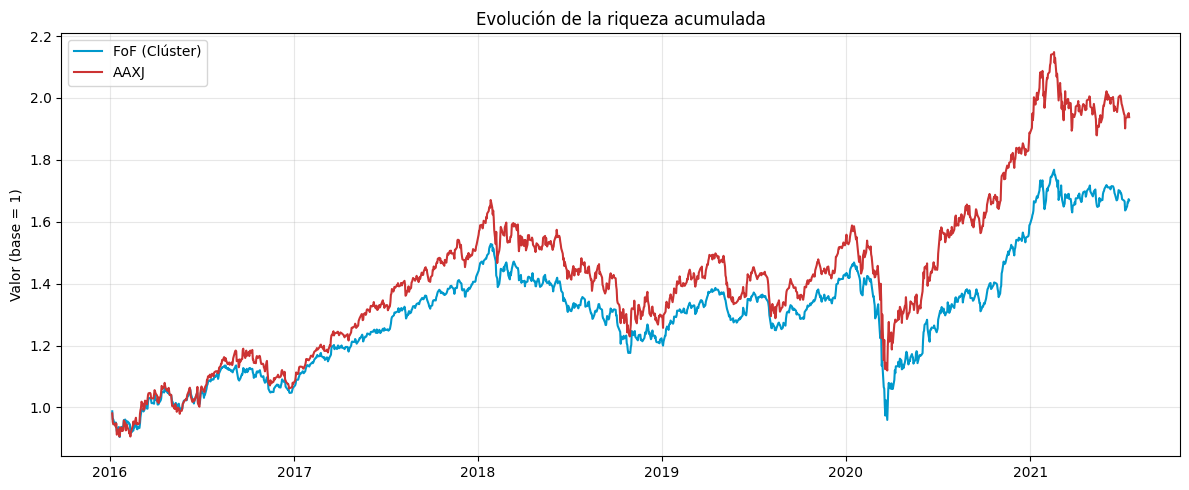

In [22]:
# --- Descarga del benchmark AAXJ (yfinance importado en la celda de librerías) ---
aaxj = yf.download("AAXJ", start="2016-01-01", end="2021-07-17", progress=False)
if isinstance(aaxj.columns, pd.MultiIndex):
    aaxj.columns = aaxj.columns.get_level_values(0)
aaxj_close = aaxj["Close"].dropna()
aaxj_close.index = pd.DatetimeIndex(aaxj_close.index).normalize()
ret_aaxj = (np.log(aaxj_close / aaxj_close.shift(1)) * 100.0).dropna().rename("AAXJ")

# Alinear FoF y benchmark
eval_df = pd.concat([ret_fof, ret_aaxj], axis=1, join="inner").dropna()
rf_eval = ff_window["RF"].reindex(eval_df.index).fillna(0)

ANN = 252

def compute_metrics(r_pct, rf_pct=None, name=""):
    r = r_pct / 100.0
    ann_ret = np.exp(r.mean() * ANN) - 1
    ann_vol = r.std() * np.sqrt(ANN)
    if rf_pct is not None:
        ex = (r_pct - rf_pct).dropna() / 100.0
    else:
        ex = r
    sharpe = (ex.mean() / ex.std()) * np.sqrt(ANN) if ex.std() > 0 else np.nan
    down = ex[ex < 0]
    sortino = (ex.mean() / down.std()) * np.sqrt(ANN) if len(down) > 1 and down.std() > 0 else np.nan
    wealth = np.exp(r.cumsum())
    dd = wealth / wealth.cummax() - 1
    max_dd = dd.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    return {
        "Estrategia": name,
        "Ret. Anual": f"{ann_ret:.2%}",
        "Vol. Anual": f"{ann_vol:.2%}",
        "Sharpe": f"{sharpe:.2f}",
        "Sortino": f"{sortino:.2f}",
        "Calmar": f"{calmar:.2f}",
        "Max DD": f"{max_dd:.2%}",
        "Obs": len(r),
    }

# Tracking Error e Information Ratio
diff = (eval_df["FoF_cluster"] - eval_df["AAXJ"]) / 100.0
te = diff.std() * np.sqrt(ANN)
ir = diff.mean() / diff.std() * np.sqrt(ANN) if diff.std() > 0 else np.nan

metrics = [
    compute_metrics(eval_df["FoF_cluster"], rf_eval, "FoF (Clúster)"),
    compute_metrics(eval_df["AAXJ"], rf_eval, "AAXJ (Benchmark)"),
]
metrics_df = pd.DataFrame(metrics).set_index("Estrategia")

print(f"Comparación de desempeño")
print(f"> Rango: {eval_df.index.min().date()} → {eval_df.index.max().date()}")
print(f"> Tracking Error: {te:.2%}")
print(f"> Information Ratio: {ir:.2f}")
display(metrics_df)

# Curvas de riqueza acumulada
fig, ax = plt.subplots(figsize=(12, 5))
for col, label, color in [("FoF_cluster", "FoF (Clúster)", "#0099CC"),
                           ("AAXJ", "AAXJ", "#CC3333")]:
    wealth = np.exp((eval_df[col] / 100.0).cumsum())
    ax.plot(wealth.index, wealth, label=label, color=color, linewidth=1.5)
ax.set_title("Evolución de la riqueza acumulada")
ax.set_ylabel("Valor (base = 1)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### <font color=#336699>**12.2. Análisis de correlación y rolling beta**</font>

Para profundizar en la validación, se analiza la correlación rolling y la beta rolling del FoF respecto al benchmark, lo que permite verificar la estabilidad temporal de la exposición asiática del fondo construido.

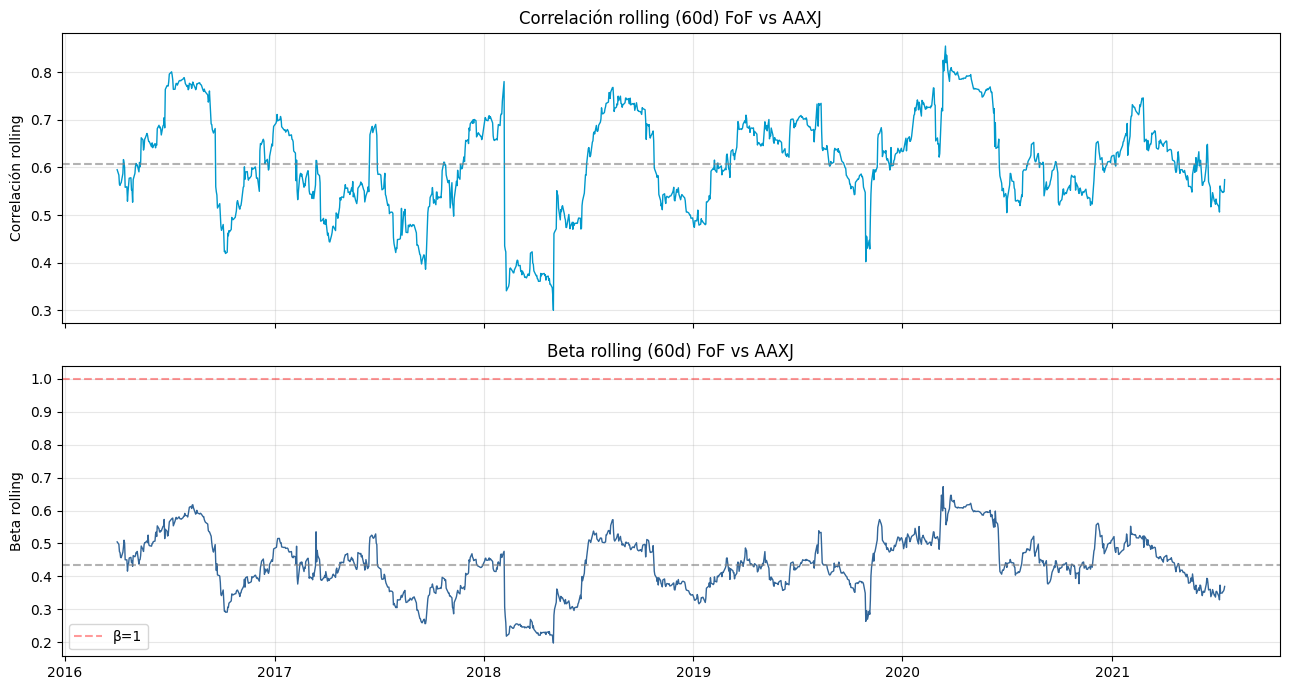

Correlación media: 0.608
Beta media: 0.436


In [23]:
# --- Correlación y beta rolling ---
WINDOW_ROLL = 60  # ~3 meses

fof_r = eval_df["FoF_cluster"]
bm_r = eval_df["AAXJ"]

rolling_corr = fof_r.rolling(WINDOW_ROLL).corr(bm_r)
rolling_beta = fof_r.rolling(WINDOW_ROLL).cov(bm_r) / bm_r.rolling(WINDOW_ROLL).var()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(rolling_corr.index, rolling_corr, color="#0099CC", linewidth=1)
axes[0].axhline(rolling_corr.mean(), ls="--", color="gray", alpha=0.6)
axes[0].set_ylabel("Correlación rolling")
axes[0].set_title(f"Correlación rolling ({WINDOW_ROLL}d) FoF vs AAXJ")
axes[0].grid(alpha=0.3)

axes[1].plot(rolling_beta.index, rolling_beta, color="#336699", linewidth=1)
axes[1].axhline(1.0, ls="--", color="red", alpha=0.4, label="β=1")
axes[1].axhline(rolling_beta.mean(), ls="--", color="gray", alpha=0.6)
axes[1].set_ylabel("Beta rolling")
axes[1].set_title(f"Beta rolling ({WINDOW_ROLL}d) FoF vs AAXJ")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

rc_m = float(rolling_corr.mean())
rb_m = float(rolling_beta.mean())
print(f"Correlación media: {rc_m:.3f}")
print(f"Beta media: {rb_m:.3f}")

> <u>Lectura guiada</u> (TEST; no usada en la construcción del FoF)
>
> **Umbrales de referencia (medias rolling):** si la correlación media es ≥0,75, la relación lineal con AAXJ en la ventana móvil es fuerte; entre 0,55 y 0,75 es moderada; por debajo de 0,55 conviene revisar núcleo indexador o *N* (sin usar AAXJ en la selección). Si la beta media está entre 0,85 y 1,15, la sensibilidad al benchmark de test es cercana a 1; por debajo de 0,85 el FoF es más conservador que el ETF; por encima de 1,15, más agresivo.
>
> **En la salida reproducida del cuaderno** (correlación media **0,608**; beta media **0,436**): la correlación rolling es **moderada** — coherente con un mandato basado en FF/MSCI distintos del índice del ETF y una cartera de fondos subyacentes. La beta rolling queda **por debajo de 1** — el FoF se comporta más conservador que AAXJ en la ventana (menor riesgo sistemático medido frente al ETF).
>
> El **tracking error** impreso en la celda anterior resume la dispersión de la diferencia de retornos FoF − AAXJ en la muestra común.

## <font color=#0099CC>**13. CONCLUSIONES**</font>

### Objetivo estratégico: Indexación al mercado asiático

El mandato de este fondo de fondos es **replicar de forma eficiente** el comportamiento del mercado de renta variable de Asia Pacífico ex Japan. Las **características** de cada fondo se construyen mediante **regresión OLS** frente a los factores regionales (aprendizaje supervisado en el sentido habitual de ML: hay una variable respuesta y covariables). La **segmentación** en grupos y la **reducción de dimensionalidad** se realizan con **PCA y clustering** (técnicas no supervisadas), sobre las que se apoya la selección del clúster y del núcleo indexador.

### Parte 1: Limpieza y Extracción de Características

- Se partió de ~25.000 fondos de inversión. Tras eliminación de fines de semana, filtro de cobertura ≥90%, forward fill (limit=5 días) y eliminación de fondos con retornos mínimos anómalos (IQR cross-sectional 1.5×), se obtuvo un universo limpio de miles de fondos.
- Los factores de Fama-French (Asia Pacific ex Japan) se convirtieron a log-retornos para coherencia con los retornos de los fondos. Se restó el RF antes de cada regresión para trabajar con retornos en exceso ("peras con peras").
- Se estimaron regresiones OLS en **tres ventanas temporales** (1, 3 y 5 años), aplicando la **corrección de coeficientes por T-value** (atenuación por significación: $\beta_{\text{adj}} = \beta \cdot (1 - e^{-|t|})$) para suprimir coeficientes ruidosos. Se calcularon betas de los 4 factores, betas up/down market, alpha, R², y métricas de riesgo (volatilidad, skewness, kurtosis, CVaR, max drawdown) por ventana.
- Se añadieron **métricas diferenciadoras**: Sharpe, Sortino, tracking error implícito y estabilidad de beta entre ventanas, orientadas a enriquecer el clustering y facilitar la identificación de fondos indexados.
- Se filtró por R² ≥ 0.30 y beta de mercado positiva y significativa (|t| ≥ 2), dejando que el clustering discrimine entre perfiles.

### Parte 2: Reducción de Dimensionalidad y Clustering

- **PCA**: la reducción de dimensionalidad comprimió las variables en componentes que explican ≥90% de la varianza. Además de sintetizar la información, el PCA **atenua la redundancia** entre variables muy correlacionadas (p. ej. la misma magnitud factorial en ventanas 1y/3y/5y), de modo que **K-Means y HAC**, basados en distancias, no queden sesgados por contar varias veces la misma señal.
- **K-Means**: el método del codo y el silhouette score guiaron la selección del número óptimo de clústeres. El perfilado financiero de cada clúster — volviendo al espacio original de variables — reveló grupos diferenciados por estilo, nivel de exposición al mercado y estabilidad.
- **HAC**: el dendrograma con linkage Ward confirmó la estructura encontrada por K-Means. La concordancia entre ambos métodos (Adjusted Rand Index, NMI) valida la robustez de los grupos.
- **Graphext**: se exportó `graphext_funds_clustering.csv` (PCs, etiquetas K-Means y HAC, variables de contexto) y se documentaron las **figuras 9.1 y 9.2** con la interpretación visual frente al dendrograma y a las métricas de concordancia (sección 9).
- Se seleccionó el clúster ganador con un **score factorial** que combina beta media, R² medio, tracking error implícito medio y proximidad de la beta a 1, además de un factor de tamaño por diversificación.
- **Segunda etapa (núcleo indexador):** dentro del clúster, se eligió un subconjunto **top-N** de fondos según un score basado en R² 5y, beta ajustada, TE implícito y penalización por alejarse de beta=1; la cartera final usa **pesos proporcionales** a ese score, renormalizados cada día entre fondos con dato. Así se reduce la dilución de fondos “puros” de renta variable con fondos de perfil mixto que solo cumplen el umbral mínimo de filtro.

### Validación frente a AAXJ (TEST)

- El FoF se contrastó con el benchmark **AAXJ** sin haberlo usado en selección ni en feature engineering. Las métricas (correlación, TE, beta rolling, ratios de Sharpe/Sortino, drawdown) deben interpretarse teniendo en cuenta que el mandato se diseñó con **factores FF** y un **índice MSCI** es un objeto distinto (composición, pesos, rebalanceos).
- La correlación rolling y la beta rolling aportan evidencia de **estabilidad temporal** de la relación con el ETF de test; su nivel absoluto refleja tanto el acierto del diseño como el **riesgo de definición** entre modelo factorial e índice de mercado.

### Limitaciones

- La evaluación tiene componente in-sample parcial (la regresión OLS y el clustering se estimaron sobre la misma ventana). En producción se recomendaría un split temporal estricto.
- La exclusión de fondos por outliers IQR podría eliminar fondos legítimos con estrategias de alto riesgo.
- El clustering depende de la parametrización (K, método de linkage, número de componentes PCA); se han evaluado múltiples configuraciones para mitigar esta dependencia.
- La **segunda etapa** (top-N del núcleo y las constantes 0,18 / 0,25 en las campanas de beta, el divisor 25 en TE) son **decisiones de gestión** explícitas: sensibilizar N o esas constantes altera el equilibrio entre **tracking** frente al factor mercado y **diversificación**. En un informe de gestión real convendría **documentar esa sensibilidad** (p. ej. variando N o las constantes de la campana) junto con la lógica de la regla de ponderación.
- Este ejercicio **no modela costes** (TER, comisiones de suscripción/reembolso, impacto de mercado), **liquidez** ni **restricciones** (regulatorias, de inversor o de elegibilidad de fondos), que condicionarían el reparto final y la viabilidad operativa de un FoF verdadero.